#### 0. 讀取 schools_list.csv

schools_list_new_1.csv 讀取完成。
資料筆數：16
欄位名稱：
['school_name', 'amenity', '縣市', '鄉鎮市區', '縣市及鄉鎮市區', '村里', 'longitude', 'latitude', 'geometry']

已成功轉換為 GeoDataFrame。
schools_gdf 筆數：16
CRS：EPSG:4326
幾何類型：['Point']

===== 前 5 筆學校圖資 =====


,school_name,amenity,縣市,鄉鎮市區,縣市及鄉鎮市區,村里,longitude,latitude,geometry
0,三民國中,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,三民里,121.349660,23.432833,POINT (121.34966 23.43283)
1,三民國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,三民里,121.348262,23.430083,POINT (121.34826 23.43008)
2,中城國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,中城里,121.317081,23.324808,POINT (121.31708 23.32481)
3,玉里國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,中城里,121.319096,23.328563,POINT (121.3191 23.32856)
4,大禹國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,大禹里,121.328828,23.379953,POINT (121.32883 23.37995)


Text(161.48990488627618, 0.5, 'Latitude')

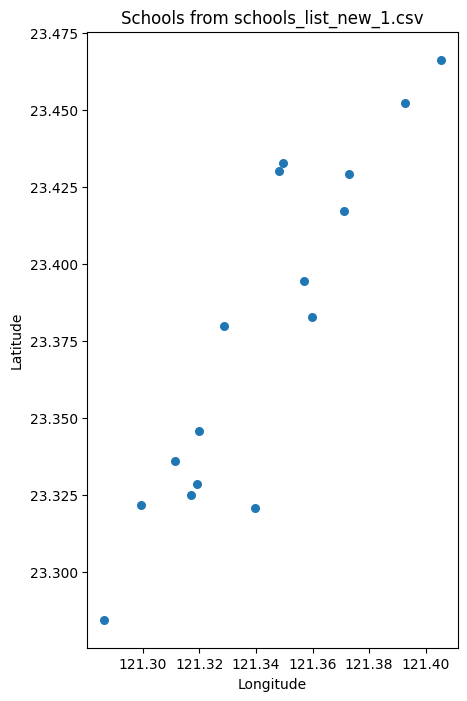

In [12]:
# ============================================================
# Cell 0：讀取 schools_list.csv 並轉為 GeoDataFrame 圖資
# ============================================================

import sys
import subprocess
from pathlib import Path

# ------------------------------------------------------------
# 1. 安裝必要套件
# ------------------------------------------------------------

packages = [
    "pandas",
    "geopandas",
    "shapely",
    "pyproj"
]

for package in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        package
    ])

# ------------------------------------------------------------
# 2. 匯入套件
# ------------------------------------------------------------

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt

# ------------------------------------------------------------
# 3. 設定資料路徑
# ------------------------------------------------------------

output_dir = Path("../output")
schools_csv_path = output_dir / "schools_list_new_1.csv"

if not schools_csv_path.exists():
    raise FileNotFoundError(
        f"找不到檔案：{schools_csv_path.resolve()}\n"
        "請確認 schools_list_new_1.csv 是否位於 ../output 資料夾中。"
    )

# ------------------------------------------------------------
# 4. 讀取 CSV
# ------------------------------------------------------------

schools_df = pd.read_csv(
    schools_csv_path,
    encoding="utf-8-sig"
)

print("schools_list_new_1.csv 讀取完成。")
print(f"資料筆數：{len(schools_df)}")
print("欄位名稱：")
print(schools_df.columns.tolist())

# ------------------------------------------------------------
# 5. 將 CSV 轉為 GeoDataFrame
# ------------------------------------------------------------
# 優先使用 longitude / latitude 建立點位 geometry
# 若沒有 longitude / latitude，則嘗試使用 geometry 欄位中的 WKT

if {"longitude", "latitude"}.issubset(schools_df.columns):

    schools_df["longitude"] = pd.to_numeric(
        schools_df["longitude"],
        errors="coerce"
    )
    schools_df["latitude"] = pd.to_numeric(
        schools_df["latitude"],
        errors="coerce"
    )

    schools_df = schools_df.dropna(
        subset=["longitude", "latitude"]
    ).copy()

    schools_gdf = gpd.GeoDataFrame(
        schools_df,
        geometry=gpd.points_from_xy(
            schools_df["longitude"],
            schools_df["latitude"]
        ),
        crs="EPSG:4326"
    )

elif "geometry" in schools_df.columns:

    schools_df["geometry"] = schools_df["geometry"].apply(wkt.loads)

    schools_gdf = gpd.GeoDataFrame(
        schools_df,
        geometry="geometry",
        crs="EPSG:4326"
    )

else:
    raise KeyError(
        "schools_list_new_1.csv 中找不到 longitude / latitude 欄位，"
        "也找不到 geometry 欄位，無法轉為圖資。"
    )

# ------------------------------------------------------------
# 6. 檢查結果
# ------------------------------------------------------------

print("\n已成功轉換為 GeoDataFrame。")
print(f"schools_gdf 筆數：{len(schools_gdf)}")
print(f"CRS：{schools_gdf.crs}")
print(f"幾何類型：{schools_gdf.geometry.geom_type.unique()}")

print("\n===== 前 5 筆學校圖資 =====")
display(schools_gdf.head())

# ------------------------------------------------------------
# 7. 簡單繪圖確認
# ------------------------------------------------------------

ax = schools_gdf.plot(
    figsize=(8, 8),
    markersize=30
)

ax.set_title("Schools from schools_list_new_1.csv")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

#### 1. 套件安裝、匯入與 schools_gdf 基本檢查

In [13]:
# ============================================================
# Cell 1：套件安裝、匯入與 schools_gdf 基本檢查
# ============================================================

import sys
import subprocess

packages = [
    "pandas",
    "numpy",
    "geopandas",
    "rasterio",
    "shapely",
    "scikit-learn",
    "pykrige"
]

for package in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        package
    ])

import os
from pathlib import Path

import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import Point
from sklearn.ensemble import RandomForestRegressor
from pykrige.ok import OrdinaryKriging

print("套件載入完成。")

# ------------------------------------------------------------
# 檢查 schools_gdf
# ------------------------------------------------------------

if "schools_gdf" not in globals():
    raise NameError("找不到 schools_gdf，請先讀取 schools_list.csv 並轉成 GeoDataFrame。")

if schools_gdf.empty:
    raise ValueError("schools_gdf 是空的，無法進行後續分析。")

if schools_gdf.crs is None:
    raise ValueError("schools_gdf 沒有 CRS，請先設定座標系統，例如 EPSG:4326。")

print("schools_gdf 檢查完成。")
print(f"學校點位數量：{len(schools_gdf)}")
print(f"CRS：{schools_gdf.crs}")
print("欄位名稱：")
print(schools_gdf.columns.tolist())

display(schools_gdf.head())

套件載入完成。
schools_gdf 檢查完成。
學校點位數量：16
CRS：EPSG:4326
欄位名稱：
['school_name', 'amenity', '縣市', '鄉鎮市區', '縣市及鄉鎮市區', '村里', 'longitude', 'latitude', 'geometry']


,school_name,amenity,縣市,鄉鎮市區,縣市及鄉鎮市區,村里,longitude,latitude,geometry
0,三民國中,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,三民里,121.349660,23.432833,POINT (121.34966 23.43283)
1,三民國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,三民里,121.348262,23.430083,POINT (121.34826 23.43008)
2,中城國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,中城里,121.317081,23.324808,POINT (121.31708 23.32481)
3,玉里國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,中城里,121.319096,23.328563,POINT (121.3191 23.32856)
4,大禹國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,大禹里,121.328828,23.379953,POINT (121.32883 23.37995)


#### 2.依土石流潛勢溪流緩衝區計算 schools_gdf 的 debrisstream_level

In [14]:
# ============================================================
# Cell 2：依土石流潛勢溪流緩衝區計算 schools_gdf 的 debrisstream_level
# ============================================================

print("正在計算學校點位的 debrisstream_level...")

# ------------------------------------------------------------
# 1. 讀取土石流緩衝區資料
# ------------------------------------------------------------

buffer_gpkg_path = Path("../data/debrisstream_hualien/stream_hualien_buffer.gpkg")

if not buffer_gpkg_path.exists():
    raise FileNotFoundError(
        f"找不到土石流緩衝區檔案：{buffer_gpkg_path.resolve()}\n"
        "請確認 ../data/debrisstream_hualien/stream_hualien_buffer.gpkg 是否存在。"
    )

buffer_500 = gpd.read_file(buffer_gpkg_path, layer="stream_hualien_buffer_500")
buffer_1000 = gpd.read_file(buffer_gpkg_path, layer="stream_hualien_buffer_1000")
buffer_1500 = gpd.read_file(buffer_gpkg_path, layer="stream_hualien_buffer_1500")

print("緩衝區資料讀取完成。")
print(f"500m：{len(buffer_500)} 筆")
print(f"1000m：{len(buffer_1000)} 筆")
print(f"1500m：{len(buffer_1500)} 筆")

# ------------------------------------------------------------
# 2. 統一座標系統
# ------------------------------------------------------------

target_crs = buffer_500.crs

schools_gdf = schools_gdf.to_crs(target_crs)
buffer_500 = buffer_500.to_crs(target_crs)
buffer_1000 = buffer_1000.to_crs(target_crs)
buffer_1500 = buffer_1500.to_crs(target_crs)

# ------------------------------------------------------------
# 3. 依距離緩衝區設定風險等級
# ------------------------------------------------------------

schools_gdf["debrisstream_level"] = "Safe"

buffer_500_union = buffer_500.geometry.union_all()
buffer_1000_union = buffer_1000.geometry.union_all()
buffer_1500_union = buffer_1500.geometry.union_all()

for idx, row in schools_gdf.iterrows():
    point = row.geometry

    if point.within(buffer_500_union):
        schools_gdf.loc[idx, "debrisstream_level"] = "High"
    elif point.within(buffer_1000_union):
        schools_gdf.loc[idx, "debrisstream_level"] = "Medium"
    elif point.within(buffer_1500_union):
        schools_gdf.loc[idx, "debrisstream_level"] = "Low"
    else:
        schools_gdf.loc[idx, "debrisstream_level"] = "Safe"

print("debrisstream_level 計算完成。")

print("\n===== debrisstream_level 統計 =====")
print(schools_gdf["debrisstream_level"].value_counts())

display_cols = ["debrisstream_level", "geometry"]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name", "debrisstream_level", "geometry"]
elif "name" in schools_gdf.columns:
    display_cols = ["name", "debrisstream_level", "geometry"]

display(schools_gdf[display_cols].head(10))

正在計算學校點位的 debrisstream_level...
緩衝區資料讀取完成。
500m：1 筆
1000m：1 筆
1500m：1 筆
debrisstream_level 計算完成。

===== debrisstream_level 統計 =====
debrisstream_level
Low       6
Safe      4
Medium    4
High      2
Name: count, dtype: int64


,school_name,debrisstream_level,geometry
0,三民國中,Safe,POINT (285729.294 2592256.698)
1,三民國小,Safe,POINT (285587.141 2591951.76)
2,中城國小,Low,POINT (282426.509 2580286.384)
3,玉里國小,Low,POINT (282631.702 2580702.6)
4,大禹國小,Medium,POINT (283613.948 2586395.726)
5,德武國小,Safe,POINT (291407.344 2595967.755)
6,春日國小,Safe,POINT (290114.676 2594407.259)
7,松浦國小,Low,POINT (288120.473 2591851.263)
8,玉東國中,High,POINT (287929.322 2590528.752)
9,樂合國小,Low,POINT (284737.781 2579848.594)


#### 3. 計算學校周邊 300m 的 Avg_slope、Max_elevation、Slope_risk_level

In [15]:
# ============================================================
# Cell 3：計算學校周邊 300m 的 Avg_slope、Max_elevation、Slope_risk_level
# ============================================================

print("正在計算學校周邊坡度與高程指標...")

# ------------------------------------------------------------
# 1. 讀取 DEM
# ------------------------------------------------------------

dem_path = Path("../data/dem_20m_hualien.tif")

if not dem_path.exists():
    raise FileNotFoundError(
        f"找不到 DEM 檔案：{dem_path.resolve()}\n"
        "請確認 ../data/dem_20m_hualien.tif 是否存在。"
    )

dem_data = rasterio.open(dem_path)

print("DEM 讀取完成。")
print(f"DEM CRS：{dem_data.crs}")
print(f"DEM shape：{dem_data.shape}")
print(f"DEM resolution：{dem_data.res}")

# ------------------------------------------------------------
# 2. 讀取高程並處理 nodata
# ------------------------------------------------------------

elevation = dem_data.read(1).astype(float)
nodata_val = dem_data.nodata

if nodata_val is not None:
    elevation = np.where(elevation == nodata_val, np.nan, elevation)

# ------------------------------------------------------------
# 3. 計算坡度
# ------------------------------------------------------------

xres = abs(dem_data.transform.a)
yres = abs(dem_data.transform.e)

elevation_filled = np.where(np.isfinite(elevation), elevation, 0)

dy, dx = np.gradient(elevation_filled, yres, xres)

slope_deg = np.degrees(
    np.arctan(
        np.sqrt(dx ** 2 + dy ** 2)
    )
)

slope_deg = np.where(np.isfinite(elevation), slope_deg, np.nan)

print("\n===== 坡度統計 =====")
print(f"平均坡度：{np.nanmean(slope_deg):.2f}°")
print(f"最大坡度：{np.nanmax(slope_deg):.2f}°")
print(f"高程範圍：{np.nanmin(elevation):.2f} - {np.nanmax(elevation):.2f} m")

# ------------------------------------------------------------
# 4. 將 schools_gdf 轉為 DEM CRS
# ------------------------------------------------------------

schools_gdf = schools_gdf.to_crs(dem_data.crs)

# ------------------------------------------------------------
# 5. 建立 300m buffer 並做 zonal statistics
# ------------------------------------------------------------

school_buffers = schools_gdf.geometry.buffer(300)

transform = dem_data.transform
height, width = dem_data.shape

avg_slopes = []
max_elevations = []

for i, buffer_geom in enumerate(school_buffers):

    if i % 20 == 0:
        print(f"處理進度：{i}/{len(school_buffers)}")

    try:
        mask = features.rasterize(
            [(buffer_geom, 1)],
            out_shape=(height, width),
            transform=transform,
            fill=0,
            dtype=np.uint8
        )

        buffer_mask = mask == 1

        if np.any(buffer_mask):
            slope_values = slope_deg[buffer_mask]
            elevation_values = elevation[buffer_mask]

            avg_slope = np.nanmean(slope_values)
            max_elevation = np.nanmax(elevation_values)

            avg_slopes.append(avg_slope)
            max_elevations.append(max_elevation)
        else:
            avg_slopes.append(np.nan)
            max_elevations.append(np.nan)

    except Exception as e:
        print(f"第 {i} 筆學校處理失敗：{e}")
        avg_slopes.append(np.nan)
        max_elevations.append(np.nan)

# ------------------------------------------------------------
# 6. 寫入欄位
# ------------------------------------------------------------

schools_gdf["Avg_slope"] = avg_slopes
schools_gdf["Max_elevation"] = max_elevations

# ------------------------------------------------------------
# 7. 依平均坡度設定風險等級
# ------------------------------------------------------------

def assign_slope_risk(avg_slope):
    """
    依附檔邏輯：
    Avg_slope > 30       → High
    20 <= Avg_slope <=30 → Medium
    Avg_slope < 20       → Low
    """
    if pd.isna(avg_slope):
        return "Unknown"
    elif avg_slope > 30:
        return "High"
    elif 20 <= avg_slope <= 30:
        return "Medium"
    else:
        return "Low"

schools_gdf["Slope_risk_level"] = schools_gdf["Avg_slope"].apply(assign_slope_risk)

print("坡度與高程指標計算完成。")

print("\n===== Slope_risk_level 統計 =====")
print(schools_gdf["Slope_risk_level"].value_counts())

display_cols = [
    "Avg_slope",
    "Max_elevation",
    "Slope_risk_level",
    "geometry"
]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name"] + display_cols
elif "name" in schools_gdf.columns:
    display_cols = ["name"] + display_cols

display(schools_gdf[display_cols].head(10))

正在計算學校周邊坡度與高程指標...
DEM 讀取完成。
DEM CRS：PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
DEM shape：(7054, 3997)
DEM resolution：(20.0, 20.0)

===== 坡度統計 =====
平均坡度：30.82°
最大坡度：89.58°
高程範圍：-3.02 - 3824.30 m
處理進度：0/16
坡度與高程指標計算完成。

===== Slope_risk_level 統計 =====
Slope_risk_level
Low    16
Name: count, dtype: int64


,school_name,Avg_slope,Max_elevation,Slope_risk_level,geometry
0,三民國中,7.891558,139.070007,Low,POINT (285729.294 2592256.698)
1,三民國小,5.905327,146.080002,Low,POINT (285587.141 2591951.76)
2,中城國小,1.269872,136.759995,Low,POINT (282426.509 2580286.384)
3,玉里國小,0.946397,130.520004,Low,POINT (282631.702 2580702.6)
4,大禹國小,1.047764,106.839996,Low,POINT (283613.948 2586395.726)
5,德武國小,7.839716,166.589996,Low,POINT (291407.344 2595967.755)
6,春日國小,3.037971,95.750000,Low,POINT (290114.676 2594407.259)
7,松浦國小,4.602562,138.850006,Low,POINT (288120.473 2591851.263)
8,玉東國中,4.522376,122.230003,Low,POINT (287929.322 2590528.752)
9,樂合國小,7.629792,191.789993,Low,POINT (284737.781 2579848.594)


#### 4. 讀取雨量測站資料並建立 x_valid、y_valid、z_valid

In [16]:
# ============================================================
# Cell 4：讀取雨量測站資料並建立 x_valid、y_valid、z_valid
# ============================================================

print("正在讀取雨量測站資料並篩選目標時間...")

# ------------------------------------------------------------
# 1. 讀取 ragasa_with_location.shp
# ------------------------------------------------------------

ragasa_path = Path("../data/ragasa_shp/ragasa_with_location.shp")

if not ragasa_path.exists():
    raise FileNotFoundError(
        f"找不到雨量測站圖資：{ragasa_path.resolve()}\n"
        "請確認 ../data/ragasa_shp/ragasa_with_location.shp 是否存在。"
    )

ragasa_gdf = gpd.read_file(ragasa_path)

print("雨量測站資料讀取完成。")
print(f"總筆數：{len(ragasa_gdf)}")
print(f"CRS：{ragasa_gdf.crs}")
print("欄位名稱：")
print(ragasa_gdf.columns.tolist())

# ------------------------------------------------------------
# 2. 篩選目標時間
# ------------------------------------------------------------

if "RST_DATE" not in ragasa_gdf.columns:
    raise KeyError("ragasa_gdf 中找不到 RST_DATE 欄位。")

if "Hour_1" not in ragasa_gdf.columns:
    raise KeyError("ragasa_gdf 中找不到 Hour_1 欄位。")

ragasa_gdf["RST_DATE"] = pd.to_datetime(
    ragasa_gdf["RST_DATE"],
    errors="coerce"
)

target_time = pd.to_datetime("2025-09-23 20:00:00")

ragasa_target = ragasa_gdf[
    ragasa_gdf["RST_DATE"] == target_time
].copy()

if ragasa_target.empty:
    raise ValueError(
        f"找不到目標時間 {target_time} 的雨量資料。\n"
        f"資料時間範圍：{ragasa_gdf['RST_DATE'].min()} ~ {ragasa_gdf['RST_DATE'].max()}"
    )

print(f"\n目標時間：{target_time}")
print(f"篩選後筆數：{len(ragasa_target)}")

# ------------------------------------------------------------
# 3. 轉為公尺座標系統
# ------------------------------------------------------------

ragasa_analysis = ragasa_target.to_crs(epsg=3826)

# ------------------------------------------------------------
# 4. 建立有效測站資料
# ------------------------------------------------------------

x = ragasa_analysis.geometry.x.values
y = ragasa_analysis.geometry.y.values
z = pd.to_numeric(ragasa_analysis["Hour_1"], errors="coerce").values

valid_mask = (z != -998) & (~np.isnan(z))

x_valid = x[valid_mask]
y_valid = y[valid_mask]
z_valid = z[valid_mask]

if len(z_valid) == 0:
    raise ValueError("沒有有效的 Hour_1 雨量資料。")

print("\n有效雨量測站資料建立完成。")
print(f"有效測站數量：{len(z_valid)}")
print(f"雨量範圍：{z_valid.min():.2f} - {z_valid.max():.2f} mm/hr")

# 將 schools_gdf 也轉成 EPSG:3826，供後續雨量推估使用
schools_gdf = schools_gdf.to_crs(epsg=3826)

print(f"schools_gdf 已轉為：{schools_gdf.crs}")

正在讀取雨量測站資料並篩選目標時間...
雨量測站資料讀取完成。
總筆數：35679
CRS：EPSG:4326
欄位名稱：
['NID', 'STID', 'MIN_10', 'Hour_1', 'Hour_3', 'Hour_6', 'Hour_12', 'Hour_24', 'RST_DATE', 'Elev', 'Stationnam', 'latitude', 'longtitude', 'altitude', 'geometry']

目標時間：2025-09-23 20:00:00
篩選後筆數：82

有效雨量測站資料建立完成。
有效測站數量：82
雨量範圍：0.00 - 80.00 mm/hr
schools_gdf 已轉為：EPSG:3826


#### 5. 使用 Ordinary Kriging 提取 schools_gdf 的 rain_1hr 與 sigma_1hr

In [17]:
# ============================================================
# Cell 5：使用 Ordinary Kriging 提取 schools_gdf 的 rain_1hr 與 sigma_1hr
# ============================================================

print("正在使用 Ordinary Kriging 推估學校點位雨量...")

# ------------------------------------------------------------
# 1. Kriging 參數
#    依照附檔中的最佳參數
# ------------------------------------------------------------

best_model = "gaussian"
best_range = 25000.0
best_sill = 0.710
best_nugget = 0.079

print("Kriging 參數：")
print(f"model  : {best_model}")
print(f"range  : {best_range}")
print(f"sill   : {best_sill}")
print(f"nugget : {best_nugget}")

# ------------------------------------------------------------
# 2. 建立 Kriging 模型
# ------------------------------------------------------------

z_valid_log = np.log1p(z_valid)

OK = OrdinaryKriging(
    x_valid,
    y_valid,
    z_valid_log,
    variogram_model=best_model,
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={
        "sill": best_sill,
        "range": best_range,
        "nugget": best_nugget
    }
)

# ------------------------------------------------------------
# 3. 取得學校點位座標
# ------------------------------------------------------------

schools_gdf = schools_gdf.to_crs(epsg=3826)

school_x = schools_gdf.geometry.x.values
school_y = schools_gdf.geometry.y.values

# ------------------------------------------------------------
# 4. 對學校點位執行 Kriging
# ------------------------------------------------------------

z_school_log, ss_school_log = OK.execute(
    "points",
    school_x,
    school_y
)

# 轉回原始雨量單位
rain_1hr = np.expm1(np.asarray(z_school_log))
rain_1hr = np.where(rain_1hr < 0, 0, rain_1hr)

# PyKrige 回傳的是 kriging variance，這裡取平方根作為 sigma
sigma_1hr = np.sqrt(np.asarray(ss_school_log))

# ------------------------------------------------------------
# 5. 寫入 schools_gdf
# ------------------------------------------------------------

schools_gdf["rain_1hr"] = rain_1hr
schools_gdf["sigma_1hr"] = sigma_1hr

print("Kriging 雨量與不確定性提取完成。")

print("\n===== rain_1hr / sigma_1hr 統計 =====")
print(schools_gdf[["rain_1hr", "sigma_1hr"]].describe())

display_cols = ["rain_1hr", "sigma_1hr", "geometry"]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name"] + display_cols
elif "name" in schools_gdf.columns:
    display_cols = ["name"] + display_cols

display(schools_gdf[display_cols].head(10))

正在使用 Ordinary Kriging 推估學校點位雨量...
Kriging 參數：
model  : gaussian
range  : 25000.0
sill   : 0.71
nugget : 0.079
Kriging 雨量與不確定性提取完成。

===== rain_1hr / sigma_1hr 統計 =====
        rain_1hr  sigma_1hr
count  16.000000  16.000000
mean   33.926728   0.314885
std    11.133796   0.006053
min    19.844025   0.308326
25%    24.736039   0.310124
50%    29.444161   0.312551
75%    46.536251   0.319403
max    48.053217   0.325462


,school_name,rain_1hr,sigma_1hr,geometry
0,三民國中,47.696512,0.312701,POINT (285729.294 2592256.698)
1,三民國小,47.866143,0.312400,POINT (285587.141 2591951.76)
2,中城國小,24.716408,0.308950,POINT (282426.509 2580286.384)
3,玉里國小,25.628226,0.309355,POINT (282631.702 2580702.6)
4,大禹國小,37.539328,0.310196,POINT (283613.948 2586395.726)
5,德武國小,20.959408,0.322621,POINT (291407.344 2595967.755)
6,春日國小,29.392408,0.325462,POINT (290114.676 2594407.259)
7,松浦國小,43.477571,0.323511,POINT (288120.473 2591851.263)
8,玉東國中,46.181722,0.324042,POINT (287929.322 2590528.752)
9,樂合國小,29.495915,0.314624,POINT (284737.781 2579848.594)


#### 6. 使用 Random Forest 推估 schools_gdf 的 rain_1hr_rf

In [18]:
# ============================================================
# Cell 6：使用 Random Forest 推估 schools_gdf 的 rain_1hr_rf
# ============================================================

print("正在使用 Random Forest 推估學校點位雨量...")

# ------------------------------------------------------------
# 1. 準備訓練資料
# ------------------------------------------------------------

X_train = np.column_stack([x_valid, y_valid])
y_train = z_valid

print(f"訓練樣本數：{len(y_train)}")
print(f"雨量範圍：{y_train.min():.2f} - {y_train.max():.2f} mm/hr")

# ------------------------------------------------------------
# 2. 建立 Random Forest 模型
#    這裡使用穩定參數，避免 GridSearch 執行過久
# ------------------------------------------------------------

best_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

# ------------------------------------------------------------
# 3. 對學校點位預測
# ------------------------------------------------------------

schools_gdf = schools_gdf.to_crs(epsg=3826)

X_school = np.column_stack([
    schools_gdf.geometry.x.values,
    schools_gdf.geometry.y.values
])

rain_1hr_rf = best_rf.predict(X_school)
rain_1hr_rf = np.where(rain_1hr_rf < 0, 0, rain_1hr_rf)

schools_gdf["rain_1hr_rf"] = rain_1hr_rf

print("Random Forest 雨量推估完成。")

print("\n===== rain_1hr_rf 統計 =====")
print(schools_gdf["rain_1hr_rf"].describe())

display_cols = ["rain_1hr_rf", "geometry"]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name"] + display_cols
elif "name" in schools_gdf.columns:
    display_cols = ["name"] + display_cols

display(schools_gdf[display_cols].head(10))

正在使用 Random Forest 推估學校點位雨量...
訓練樣本數：82
雨量範圍：0.00 - 80.00 mm/hr
Random Forest 雨量推估完成。

===== rain_1hr_rf 統計 =====
count    16.000000
mean     37.436771
std      11.981788
min      19.883333
25%      28.470000
50%      33.105833
75%      47.814583
max      54.156667
Name: rain_1hr_rf, dtype: float64


,school_name,rain_1hr_rf,geometry
0,三民國中,47.728333,POINT (285729.294 2592256.698)
1,三民國小,47.495000,POINT (285587.141 2591951.76)
2,中城國小,28.546667,POINT (282426.509 2580286.384)
3,玉里國小,28.240000,POINT (282631.702 2580702.6)
4,大禹國小,49.661667,POINT (283613.948 2586395.726)
5,德武國小,23.605000,POINT (291407.344 2595967.755)
6,春日國小,34.056667,POINT (290114.676 2594407.259)
7,松浦國小,47.670000,POINT (288120.473 2591851.263)
8,玉東國中,48.073333,POINT (287929.322 2590528.752)
9,樂合國小,30.838333,POINT (284737.781 2579848.594)


#### 7. 加入 village_A65UP_CNT 高齡人口資料

In [19]:
# ============================================================
# Cell 7：加入 village_A65UP_CNT 高齡人口資料
# ============================================================

print("正在加入村里 65 歲以上人口資料...")

# ------------------------------------------------------------
# 1. 讀取 age_df
# ------------------------------------------------------------

age_csv_path = Path("../data/114年12月行政區三段年齡組性別人口統計_村里_花蓮縣.csv")

if not age_csv_path.exists():
    raise FileNotFoundError(
        f"找不到人口統計檔案：{age_csv_path.resolve()}\n"
        "請確認人口統計 CSV 是否位於 ../data/。"
    )

age_df = pd.read_csv(age_csv_path, encoding="utf-8")

required_age_cols = ["VILLAGE", "A65UP_CNT"]
missing_age_cols = [
    col for col in required_age_cols
    if col not in age_df.columns
]

if len(missing_age_cols) > 0:
    raise KeyError(
        f"age_df 缺少必要欄位：{missing_age_cols}\n"
        f"目前欄位有：{age_df.columns.tolist()}"
    )

# ------------------------------------------------------------
# 2. 若 schools_gdf 沒有村里欄位，嘗試用村里界線做 spatial join
# ------------------------------------------------------------

if "村里" not in schools_gdf.columns:

    print("schools_gdf 沒有「村里」欄位，嘗試讀取村里界線並進行空間套疊。")

    candidate_village_paths = [
        Path("../data/村里界線/VILLAGE_MOI_1140318.shp"),
        Path("../data/村里界線/VILLAGE_MOI_1140318.shp"),
        Path("../data/VILLAGE_MOI_1140318.shp"),
        Path("../data/村里界線/VILLAGE_MOI_1130718.shp"),
    ]

    village_path = None

    for path in candidate_village_paths:
        if path.exists():
            village_path = path
            break

    if village_path is None:
        raise FileNotFoundError(
            "schools_gdf 沒有「村里」欄位，且找不到村里界線圖資。\n"
            "請確認村里界線 shp 是否存在，或先在 schools_gdf 中建立「村里」欄位。"
        )

    village_gdf = gpd.read_file(village_path)

    print(f"已讀取村里界線：{village_path}")
    print(f"村里界線筆數：{len(village_gdf)}")
    print(f"村里界線 CRS：{village_gdf.crs}")

    # 篩選花蓮縣
    if "COUNTYNAME" in village_gdf.columns:
        village_gdf = village_gdf[
            village_gdf["COUNTYNAME"].astype(str).str.strip() == "花蓮縣"
        ].copy()

    # 找出村里名稱欄位
    possible_village_name_cols = [
        "VILLNAME",
        "VILLAGE",
        "村里",
        "村里名稱",
        "VILLAGE_NAME"
    ]

    village_name_col = None

    for col in possible_village_name_cols:
        if col in village_gdf.columns:
            village_name_col = col
            break

    if village_name_col is None:
        raise KeyError(
            "村里界線中找不到村里名稱欄位。\n"
            f"目前欄位有：{village_gdf.columns.tolist()}"
        )

    village_gdf = village_gdf.to_crs(schools_gdf.crs)

    schools_join = gpd.sjoin(
        schools_gdf,
        village_gdf[[village_name_col, "geometry"]],
        how="left",
        predicate="within"
    )

    schools_join = schools_join.drop(
        columns=["index_right"],
        errors="ignore"
    )

    schools_join = schools_join.rename(
        columns={village_name_col: "村里"}
    )

    schools_gdf = schools_join.copy()

else:
    print("schools_gdf 已有「村里」欄位，直接進行人口資料 join。")

# ------------------------------------------------------------
# 3. 建立 join key
# ------------------------------------------------------------

schools_gdf["村里_join_key"] = (
    schools_gdf["村里"]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

age_df["VILLAGE_join_key"] = (
    age_df["VILLAGE"]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

age_df["A65UP_CNT"] = pd.to_numeric(
    age_df["A65UP_CNT"],
    errors="coerce"
)

age_village = (
    age_df
    .groupby("VILLAGE_join_key", as_index=False)
    .agg({"A65UP_CNT": "sum"})
    .rename(columns={"A65UP_CNT": "village_A65UP_CNT"})
)

# ------------------------------------------------------------
# 4. Join 高齡人口數
# ------------------------------------------------------------

schools_gdf = schools_gdf.merge(
    age_village,
    how="left",
    left_on="村里_join_key",
    right_on="VILLAGE_join_key"
)

schools_gdf = schools_gdf.drop(
    columns=["村里_join_key", "VILLAGE_join_key"],
    errors="ignore"
)

print("village_A65UP_CNT 加入完成。")

matched_count = schools_gdf["village_A65UP_CNT"].notna().sum()
total_count = len(schools_gdf)

print(f"成功匹配：{matched_count}/{total_count}")
print(f"未匹配：{total_count - matched_count}")

display_cols = ["村里", "village_A65UP_CNT", "geometry"]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name"] + display_cols
elif "name" in schools_gdf.columns:
    display_cols = ["name"] + display_cols

display(schools_gdf[display_cols].head(10))

正在加入村里 65 歲以上人口資料...
schools_gdf 已有「村里」欄位，直接進行人口資料 join。
village_A65UP_CNT 加入完成。
成功匹配：16/16
未匹配：0


,school_name,村里,village_A65UP_CNT,geometry
0,三民國中,三民里,241.0,POINT (285729.294 2592256.698)
1,三民國小,三民里,241.0,POINT (285587.141 2591951.76)
2,中城國小,中城里,1273.0,POINT (282426.509 2580286.384)
3,玉里國小,中城里,1273.0,POINT (282631.702 2580702.6)
4,大禹國小,大禹里,271.0,POINT (283613.948 2586395.726)
5,德武國小,德武里,210.0,POINT (291407.344 2595967.755)
6,春日國小,春日里,215.0,POINT (290114.676 2594407.259)
7,松浦國小,松浦里,342.0,POINT (288120.473 2591851.263)
8,玉東國中,松浦里,342.0,POINT (287929.322 2590528.752)
9,樂合國小,樂合里,301.0,POINT (284737.781 2579848.594)


#### 8. 檢查 schools_gdf 目標欄位並輸出結果

In [20]:
# ============================================================
# Cell 8：檢查 schools_gdf 目標欄位並輸出結果
# ============================================================

print("正在檢查 schools_gdf 目標欄位...")

target_cols = [
    "debrisstream_level",
    "Avg_slope",
    "Max_elevation",
    "Slope_risk_level",
    "rain_1hr",
    "sigma_1hr",
    "rain_1hr_rf",
    "village_A65UP_CNT"
]

missing_cols = [
    col for col in target_cols
    if col not in schools_gdf.columns
]

if len(missing_cols) > 0:
    print("以下欄位尚未建立：")
    print(missing_cols)
else:
    print("所有目標欄位皆已建立完成。")

print("\n===== 目標欄位缺值統計 =====")
print(schools_gdf[target_cols].isna().sum())

print("\n===== 目標欄位資料型態 =====")
print(schools_gdf[target_cols].dtypes)

display_cols = target_cols + ["geometry"]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name"] + display_cols
elif "name" in schools_gdf.columns:
    display_cols = ["name"] + display_cols

print("\n===== schools_gdf 結果預覽 =====")
display(schools_gdf[display_cols].head(20))

'''# ------------------------------------------------------------
# 輸出為 GeoPackage 與 CSV
# ------------------------------------------------------------

output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

schools_output_gpkg = output_dir / "schools_gdf_with_risk_factors.gpkg"
schools_output_csv = output_dir / "schools_gdf_with_risk_factors.csv"

schools_gdf.to_file(
    schools_output_gpkg,
    layer="schools_gdf_with_risk_factors",
    driver="GPKG",
    encoding="utf-8"
)

# CSV 會保留 geometry 為 WKT 文字
schools_gdf.to_csv(
    schools_output_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\n輸出完成。")
print(f"GeoPackage：{schools_output_gpkg}")
print(f"CSV：{schools_output_csv}")'''

正在檢查 schools_gdf 目標欄位...
所有目標欄位皆已建立完成。

===== 目標欄位缺值統計 =====
debrisstream_level    0
Avg_slope             0
Max_elevation         0
Slope_risk_level      0
rain_1hr              0
sigma_1hr             0
rain_1hr_rf           0
village_A65UP_CNT     0
dtype: int64

===== 目標欄位資料型態 =====
debrisstream_level     object
Avg_slope             float64
Max_elevation         float64
Slope_risk_level       object
rain_1hr              float64
sigma_1hr             float64
rain_1hr_rf           float64
village_A65UP_CNT     float64
dtype: object

===== schools_gdf 結果預覽 =====


,school_name,debrisstream_level,Avg_slope,Max_elevation,Slope_risk_level,rain_1hr,sigma_1hr,rain_1hr_rf,village_A65UP_CNT,geometry
0,三民國中,Safe,7.891558,139.070007,Low,47.696512,0.312701,47.728333,241.0,POINT (285729.294 2592256.698)
1,三民國小,Safe,5.905327,146.080002,Low,47.866143,0.312400,47.495000,241.0,POINT (285587.141 2591951.76)
2,中城國小,Low,1.269872,136.759995,Low,24.716408,0.308950,28.546667,1273.0,POINT (282426.509 2580286.384)
3,玉里國小,Low,0.946397,130.520004,Low,25.628226,0.309355,28.240000,1273.0,POINT (282631.702 2580702.6)
4,大禹國小,Medium,1.047764,106.839996,Low,37.539328,0.310196,49.661667,271.0,POINT (283613.948 2586395.726)
5,德武國小,Safe,7.839716,166.589996,Low,20.959408,0.322621,23.605000,210.0,POINT (291407.344 2595967.755)
6,春日國小,Safe,3.037971,95.750000,Low,29.392408,0.325462,34.056667,215.0,POINT (290114.676 2594407.259)
7,松浦國小,Low,4.602562,138.850006,Low,43.477571,0.323511,47.670000,342.0,POINT (288120.473 2591851.263)
8,玉東國中,High,4.522376,122.230003,Low,46.181722,0.324042,48.073333,342.0,POINT (287929.322 2590528.752)
9,樂合國小,Low,7.629792,191.789993,Low,29.495915,0.314624,30.838333,301.0,POINT (284737.781 2579848.594)


'# ------------------------------------------------------------\n# 輸出為 GeoPackage 與 CSV\n# ------------------------------------------------------------\n\noutput_dir = Path("../output")\noutput_dir.mkdir(parents=True, exist_ok=True)\n\nschools_output_gpkg = output_dir / "schools_gdf_with_risk_factors.gpkg"\nschools_output_csv = output_dir / "schools_gdf_with_risk_factors.csv"\n\nschools_gdf.to_file(\n    schools_output_gpkg,\n    layer="schools_gdf_with_risk_factors",\n    driver="GPKG",\n    encoding="utf-8"\n)\n\n# CSV 會保留 geometry 為 WKT 文字\nschools_gdf.to_csv(\n    schools_output_csv,\n    index=False,\n    encoding="utf-8-sig"\n)\n\nprint("\n輸出完成。")\nprint(f"GeoPackage：{schools_output_gpkg}")\nprint(f"CSV：{schools_output_csv}")'

#### 9. 讀取 risk_grid_30m_new.gpkg，依 schools_gdf 點位提取所屬網格 fusion_class / fusion_label

In [21]:
# ============================================================
# Cell：讀取 risk_grid_30m.gpkg，依 schools_gdf 點位提取所屬網格 fusion_class / fusion_label
# ============================================================

from pathlib import Path
import geopandas as gpd
import pandas as pd
import fiona

print("正在讀取 risk_grid_30m.gpkg，並依學校點位提取所屬網格資訊...")

# ------------------------------------------------------------
# 1. 檢查 schools_gdf 是否存在
# ------------------------------------------------------------

if "schools_gdf" not in globals():
    raise NameError("找不到 schools_gdf，請先執行學校點位圖資讀取或建立的 Cell。")

if schools_gdf.empty:
    raise ValueError("schools_gdf 是空的，無法進行網格套疊。")

if schools_gdf.crs is None:
    raise ValueError("schools_gdf 沒有 CRS，請先確認 schools_gdf 的座標系統。")

print("schools_gdf 檢查完成。")
print(f"schools_gdf 筆數：{len(schools_gdf)}")
print(f"schools_gdf CRS：{schools_gdf.crs}")

# ------------------------------------------------------------
# 2. 設定 risk_grid_30m.gpkg 路徑
# ------------------------------------------------------------

risk_grid_path = Path("../data/risk_grid_30m_new.gpkg")

if not risk_grid_path.exists():
    raise FileNotFoundError(
        f"找不到 risk_grid_30m.gpkg：{risk_grid_path.resolve()}\n"
        "請確認檔案是否位於 ../data 資料夾中。"
    )

# ------------------------------------------------------------
# 3. 讀取 GPKG 圖層
# ------------------------------------------------------------

layers = fiona.listlayers(risk_grid_path)

print("\n===== risk_grid_30m.gpkg 圖層列表 =====")
print(layers)

# 若 GPKG 只有一個圖層，直接讀第一個圖層
risk_grid_layer = layers[0]

risk_grid_gdf = gpd.read_file(
    risk_grid_path,
    layer=risk_grid_layer
)

print("\nrisk_grid_30m.gpkg 讀取完成。")
print(f"使用圖層：{risk_grid_layer}")
print(f"risk_grid_gdf 筆數：{len(risk_grid_gdf)}")
print(f"risk_grid_gdf CRS：{risk_grid_gdf.crs}")
print("risk_grid_gdf 欄位：")
print(risk_grid_gdf.columns.tolist())

# ------------------------------------------------------------
# 4. 檢查必要欄位
# ------------------------------------------------------------

required_grid_cols = [
    "fusion_class",
    "fusion_label",
    "geometry"
]

missing_grid_cols = [
    col for col in required_grid_cols
    if col not in risk_grid_gdf.columns
]

if len(missing_grid_cols) > 0:
    raise KeyError(
        f"risk_grid_gdf 缺少必要欄位：{missing_grid_cols}\n"
        f"目前欄位有：{risk_grid_gdf.columns.tolist()}"
    )

if risk_grid_gdf.crs is None:
    raise ValueError("risk_grid_gdf 沒有 CRS，無法與 schools_gdf 進行空間套疊。")

# ------------------------------------------------------------
# 5. 準備空間套疊資料
# ------------------------------------------------------------
# 為了不改變原本 schools_gdf 的 CRS，先複製一份用於 spatial join。

schools_original_crs = schools_gdf.crs

schools_for_join = schools_gdf.copy()
schools_for_join["school_id_join"] = range(len(schools_for_join))

# 轉成 risk_grid_gdf 的 CRS
schools_for_join = schools_for_join.to_crs(risk_grid_gdf.crs)

# 只保留 risk_grid 需要的欄位
risk_grid_for_join = risk_grid_gdf[
    [
        "fusion_class",
        "fusion_label",
        "geometry"
    ]
].copy()

# ------------------------------------------------------------
# 6. 清除 schools_gdf 中既有的 fusion_class / fusion_label，避免重複欄位
# ------------------------------------------------------------

schools_gdf = schools_gdf.drop(
    columns=[
        "fusion_class",
        "fusion_label"
    ],
    errors="ignore"
)

# ------------------------------------------------------------
# 7. Spatial Join：找出每個學校點位所屬網格
# ------------------------------------------------------------
# 使用 within：學校點位必須位於網格 polygon 內。

schools_joined = gpd.sjoin(
    schools_for_join,
    risk_grid_for_join,
    how="left",
    predicate="within"
)

schools_joined = schools_joined.drop(
    columns=["index_right"],
    errors="ignore"
)

# ------------------------------------------------------------
# 8. 若同一個點位意外對應到多個網格，只保留第一筆
# ------------------------------------------------------------

schools_joined_unique = (
    schools_joined
    .sort_values("school_id_join")
    .drop_duplicates(subset=["school_id_join"], keep="first")
    [
        [
            "school_id_join",
            "fusion_class",
            "fusion_label"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------
# 9. 將 fusion_class / fusion_label 加回原本 schools_gdf
# ------------------------------------------------------------

schools_gdf = schools_gdf.copy()
schools_gdf["school_id_join"] = range(len(schools_gdf))

schools_gdf = schools_gdf.merge(
    schools_joined_unique,
    how="left",
    on="school_id_join"
)

schools_gdf = schools_gdf.drop(
    columns=["school_id_join"],
    errors="ignore"
)

# 確保仍然是 GeoDataFrame
schools_gdf = gpd.GeoDataFrame(
    schools_gdf,
    geometry="geometry",
    crs=schools_original_crs
)

# ------------------------------------------------------------
# 10. 檢查結果
# ------------------------------------------------------------

matched_count = schools_gdf["fusion_class"].notna().sum()
total_count = len(schools_gdf)

print("\n網格屬性提取完成。")
print(f"成功取得 fusion_class / fusion_label：{matched_count}/{total_count}")
print(f"未匹配到網格：{total_count - matched_count}")

print("\n===== fusion_class 統計 =====")
print(schools_gdf["fusion_class"].value_counts(dropna=False))

print("\n===== fusion_label 統計 =====")
print(schools_gdf["fusion_label"].value_counts(dropna=False))

# ------------------------------------------------------------
# 11. 顯示結果
# ------------------------------------------------------------

display_cols = [
    "fusion_class",
    "fusion_label",
    "geometry"
]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name"] + display_cols
elif "name" in schools_gdf.columns:
    display_cols = ["name"] + display_cols

print("\n===== schools_gdf 加入 fusion_class / fusion_label 後預覽 =====")
display(schools_gdf[display_cols].head(20))

正在讀取 risk_grid_30m.gpkg，並依學校點位提取所屬網格資訊...
schools_gdf 檢查完成。
schools_gdf 筆數：16
schools_gdf CRS：EPSG:3826

===== risk_grid_30m.gpkg 圖層列表 =====
['risk_grid']

risk_grid_30m.gpkg 讀取完成。
使用圖層：risk_grid
risk_grid_gdf 筆數：5631246
risk_grid_gdf CRS：EPSG:32651
risk_grid_gdf 欄位：
['ndvi_post', 'ndwi_post', 'fusion_class', 'fusion_label', 'geometry']

網格屬性提取完成。
成功取得 fusion_class / fusion_label：6/16
未匹配到網格：10

===== fusion_class 統計 =====
fusion_class
NaN    10
0.0     6
Name: count, dtype: int64

===== fusion_label 統計 =====
fusion_label
NaN    10
無淹水     6
Name: count, dtype: int64

===== schools_gdf 加入 fusion_class / fusion_label 後預覽 =====


,school_name,fusion_class,fusion_label,geometry
0,三民國中,0.0,無淹水,POINT (285729.294 2592256.698)
1,三民國小,0.0,無淹水,POINT (285587.141 2591951.76)
2,中城國小,NaN,NaN,POINT (282426.509 2580286.384)
3,玉里國小,NaN,NaN,POINT (282631.702 2580702.6)
4,大禹國小,NaN,NaN,POINT (283613.948 2586395.726)
5,德武國小,0.0,無淹水,POINT (291407.344 2595967.755)
6,春日國小,0.0,無淹水,POINT (290114.676 2594407.259)
7,松浦國小,0.0,無淹水,POINT (288120.473 2591851.263)
8,玉東國中,0.0,無淹水,POINT (287929.322 2590528.752)
9,樂合國小,NaN,NaN,POINT (284737.781 2579848.594)


In [22]:
schools_gdf

,school_name,amenity,縣市,鄉鎮市區,縣市及鄉鎮市區,村里,longitude,latitude,geometry,debrisstream_level,Avg_slope,Max_elevation,Slope_risk_level,rain_1hr,sigma_1hr,rain_1hr_rf,village_A65UP_CNT,fusion_class,fusion_label
0,三民國中,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,三民里,121.349660,23.432833,POINT (285729.294 2592256.698),Safe,7.891558,139.070007,Low,47.696512,0.312701,47.728333,241.0,0.0,無淹水
1,三民國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,三民里,121.348262,23.430083,POINT (285587.141 2591951.76),Safe,5.905327,146.080002,Low,47.866143,0.312400,47.495000,241.0,0.0,無淹水
2,中城國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,中城里,121.317081,23.324808,POINT (282426.509 2580286.384),Low,1.269872,136.759995,Low,24.716408,0.308950,28.546667,1273.0,NaN,NaN
3,玉里國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,中城里,121.319096,23.328563,POINT (282631.702 2580702.6),Low,0.946397,130.520004,Low,25.628226,0.309355,28.240000,1273.0,NaN,NaN
4,大禹國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,大禹里,121.328828,23.379953,POINT (283613.948 2586395.726),Medium,1.047764,106.839996,Low,37.539328,0.310196,49.661667,271.0,NaN,NaN
5,德武國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,德武里,121.405329,23.466210,POINT (291407.344 2595967.755),Safe,7.839716,166.589996,Low,20.959408,0.322621,23.605000,210.0,0.0,無淹水
6,春日國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,春日里,121.392634,23.452151,POINT (290114.676 2594407.259),Safe,3.037971,95.750000,Low,29.392408,0.325462,34.056667,215.0,0.0,無淹水
7,松浦國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,松浦里,121.373050,23.429118,POINT (288120.473 2591851.263),Low,4.602562,138.850006,Low,43.477571,0.323511,47.670000,342.0,0.0,無淹水
8,玉東國中,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,松浦里,121.371146,23.417180,POINT (287929.322 2590528.752),High,4.522376,122.230003,Low,46.181722,0.324042,48.073333,342.0,0.0,無淹水
9,樂合國小,school,花蓮縣,玉里鎮,花蓮縣玉里鎮,樂合里,121.339671,23.320808,POINT (284737.781 2579848.594),Low,7.629792,191.789993,Low,29.495915,0.314624,30.838333,301.0,NaN,NaN


#### 10. 計算每個學校點位的風險分數

In [23]:
# ============================================================
# Cell：依 schools_gdf 欄位計算每個學校點位的風險分數
#       不進行 0-100 拉伸，只計算公式原始分數
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd

print("正在計算 schools_gdf 每個學校點位的原始風險分數...")

# ------------------------------------------------------------
# 1. 檢查 schools_gdf 是否存在
# ------------------------------------------------------------

if "schools_gdf" not in globals():
    raise NameError("找不到 schools_gdf，請先執行前面的學校圖資建立與欄位提取 Cell。")

if schools_gdf.empty:
    raise ValueError("schools_gdf 是空的，無法計算風險分數。")

df = schools_gdf.copy()

# ------------------------------------------------------------
# 2. 處理欄位名稱差異
# ------------------------------------------------------------
# 你的資料中可能是 debrisstream_level，也可能是 debris_stream_level
# 統一成 debris_stream_level 供後續計算使用

if "debris_stream_level" not in df.columns and "debrisstream_level" in df.columns:
    df["debris_stream_level"] = df["debrisstream_level"]

# ------------------------------------------------------------
# 3. 檢查必要欄位
# ------------------------------------------------------------

required_cols = [
    "rain_1hr",
    "fusion_class",
    "debris_stream_level",
    "Max_elevation",
    "Slope_risk_level",
    "sigma_1hr",
    "village_A65UP_CNT"
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if len(missing_cols) > 0:
    raise KeyError(
        f"schools_gdf 缺少必要欄位：{missing_cols}\n"
        f"目前欄位有：{df.columns.tolist()}"
    )

# ------------------------------------------------------------
# 4. 工具函數
# ------------------------------------------------------------

def minmax_normalize(series, higher_is_risk=True):
    """
    一般 min-max 標準化。
    
    higher_is_risk=True：
        數值越大，風險越高。
    
    higher_is_risk=False：
        數值越大，風險越低。
    """
    s = pd.to_numeric(series, errors="coerce")
    
    if s.notna().sum() == 0:
        return pd.Series(0.0, index=series.index)
    
    s = s.fillna(s.median())
    
    s_min = s.min()
    s_max = s.max()
    
    if s_max == s_min:
        norm = pd.Series(0.0, index=series.index)
    else:
        norm = (s - s_min) / (s_max - s_min)
    
    if not higher_is_risk:
        norm = 1 - norm
    
    return norm.clip(0, 1)


def map_level_to_score(series):
    """
    Safe / Low / Medium / High 轉成 0-1 風險分數。
    """
    level_map = {
        "safe": 0.00,
        "low": 0.33,
        "medium": 0.67,
        "high": 1.00
    }
    
    s = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
    )
    
    return s.map(level_map).fillna(0.0)


def map_fusion_class(series):
    
    collapse_classes = [2, 3]
    
    s = pd.to_numeric(series, errors="coerce")
    
    return s.apply(
        lambda x: 1.0 if x in collapse_classes else 0.0
    )

# ------------------------------------------------------------
# 5. 建立各項 0-1 風險分數
# ------------------------------------------------------------

# 5.1 雨量風險：rain_1hr 越大越差
df["risk_rain"] = minmax_normalize(
    df["rain_1hr"],
    higher_is_risk=True
)

# 5.2 崩塌暴露風險：fusion_class 依指定類別轉換
df["risk_collapse"] = map_fusion_class(
    df["fusion_class"]
)

# 5.3 土石流 / 潛勢溪流風險：Safe < Low < Medium < High
df["risk_debris_stream"] = map_level_to_score(
    df["debris_stream_level"]
)

# 5.4 最大高程風險：Max_elevation 越大越差
df["risk_max_elevation"] = minmax_normalize(
    df["Max_elevation"],
    higher_is_risk=True
)

# 5.5 坡度風險等級：Low < Medium < High
df["risk_slope_level"] = map_level_to_score(
    df["Slope_risk_level"]
)

# 5.6 Kriging 不確定性：sigma_1hr 越大越差
df["risk_uncertainty"] = minmax_normalize(
    df["sigma_1hr"],
    higher_is_risk=True
)

# 5.7 社會脆弱度：高齡人口越多越差
# 使用 log1p 降低極端人口數影響
df["risk_elderly"] = minmax_normalize(
    np.log1p(pd.to_numeric(df["village_A65UP_CNT"], errors="coerce")),
    higher_is_risk=True
)

# ------------------------------------------------------------
# 6. 計算 Hazard 分數
# ------------------------------------------------------------

df["hazard_score"] = (
    0.15 * df["risk_rain"] +
    0.30 * df["risk_collapse"] +
    0.15 * df["risk_debris_stream"] +
    0.15 * df["risk_max_elevation"] +
    0.15 * df["risk_slope_level"] +
    0.10 * df["risk_uncertainty"]
).clip(0, 1)

# ------------------------------------------------------------
# 7. 社會脆弱度放大係數
# ------------------------------------------------------------

df["vulnerability_multiplier"] = (
    0.70 + 0.30 * df["risk_elderly"]
)

# ------------------------------------------------------------
# 8. 計算原始學校風險分數
# ------------------------------------------------------------
# 不進行 0-100 拉伸。
# school_risk_score 的理論範圍約為 0-1。

df["school_risk_score"] = (
    df["hazard_score"] *
    df["vulnerability_multiplier"]*100
) .clip(0, 100)

# ------------------------------------------------------------
# 9. 依原始分數分類風險等級
# ------------------------------------------------------------
# 這裡使用 0-1 原始分數分級，不是 0-100 分數。

def classify_school_risk(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Medium"
    elif score < 75:
        return "High"
    else:
        return "Very High"

df["school_risk_level"] = df["school_risk_score"].apply(classify_school_risk)

# ------------------------------------------------------------
# 10. 回寫到 schools_gdf
# ------------------------------------------------------------

schools_gdf = df.copy()

if not isinstance(schools_gdf, gpd.GeoDataFrame):
    schools_gdf = gpd.GeoDataFrame(
        schools_gdf,
        geometry="geometry",
        crs=df.crs if hasattr(df, "crs") else None
    )

print("schools_gdf 學校風險分數計算完成。")

# ------------------------------------------------------------
# 11. 檢查結果
# ------------------------------------------------------------

print("\n===== school_risk_score 統計 =====")
print(schools_gdf["school_risk_score"].describe())

print("\n===== school_risk_level 數量 =====")
print(schools_gdf["school_risk_level"].value_counts())

print("\n===== 各風險因子缺值統計 =====")
check_cols = [
    "rain_1hr",
    "fusion_class",
    "debris_stream_level",
    "Max_elevation",
    "Slope_risk_level",
    "sigma_1hr",
    "village_A65UP_CNT",
    "school_risk_score",
    "school_risk_level"
]

print(schools_gdf[check_cols].isna().sum())

print("\n===== 前 10 筆學校風險結果 =====")

display_cols = [
    "rain_1hr",
    "fusion_class",
    "debris_stream_level",
    "Max_elevation",
    "Slope_risk_level",
    "sigma_1hr",
    "village_A65UP_CNT",
    "risk_rain",
    "risk_collapse",
    "risk_debris_stream",
    "risk_max_elevation",
    "risk_slope_level",
    "risk_uncertainty",
    "risk_elderly",
    "hazard_score",
    "vulnerability_multiplier",
    "school_risk_score",
    "school_risk_level",
    "geometry"
]

if "school_name" in schools_gdf.columns:
    display_cols = ["school_name"] + display_cols
elif "name" in schools_gdf.columns:
    display_cols = ["name"] + display_cols

display(schools_gdf[display_cols].head(10))

正在計算 schools_gdf 每個學校點位的原始風險分數...
schools_gdf 學校風險分數計算完成。

===== school_risk_score 統計 =====
count    16.000000
mean     23.376082
std       7.812914
min      15.214533
25%      16.878284
50%      20.987281
75%      26.029077
max      38.137917
Name: school_risk_score, dtype: float64

===== school_risk_level 數量 =====
school_risk_level
Low       12
Medium     4
Name: count, dtype: int64

===== 各風險因子缺值統計 =====
rain_1hr                0
fusion_class           10
debris_stream_level     0
Max_elevation           0
Slope_risk_level        0
sigma_1hr               0
village_A65UP_CNT       0
school_risk_score       0
school_risk_level       0
dtype: int64

===== 前 10 筆學校風險結果 =====


,school_name,rain_1hr,fusion_class,debris_stream_level,Max_elevation,Slope_risk_level,sigma_1hr,village_A65UP_CNT,risk_rain,risk_collapse,risk_debris_stream,risk_max_elevation,risk_slope_level,risk_uncertainty,risk_elderly,hazard_score,vulnerability_multiplier,school_risk_score,school_risk_level,geometry
0,三民國中,47.696512,0.0,Safe,139.070007,Low,0.312701,241.0,0.987355,0.0,0.00,0.276664,0.33,0.255347,0.250272,0.264638,0.775082,20.511571,Low,POINT (285729.294 2592256.698)
1,三民國小,47.866143,0.0,Safe,146.080002,Low,0.312400,241.0,0.993368,0.0,0.00,0.321433,0.33,0.237763,0.250272,0.270497,0.775082,20.965692,Low,POINT (285587.141 2591951.76)
2,中城國小,24.716408,NaN,Low,136.759995,Low,0.308950,1273.0,0.172723,0.0,0.33,0.261911,0.33,0.036443,1.000000,0.167839,1.000000,16.783940,Low,POINT (282426.509 2580286.384)
3,玉里國小,25.628226,NaN,Low,130.520004,Low,0.309355,1273.0,0.205047,0.0,0.33,0.222059,0.33,0.060039,1.000000,0.169070,1.000000,16.906974,Low,POINT (282631.702 2580702.6)
4,大禹國小,37.539328,NaN,Medium,106.839996,Low,0.310196,271.0,0.627289,0.0,0.67,0.070826,0.33,0.109130,0.303022,0.265630,0.790907,21.008871,Low,POINT (283613.948 2586395.726)
5,德武國小,20.959408,0.0,Safe,166.589996,Low,0.322621,210.0,0.039540,0.0,0.00,0.452420,0.33,0.834217,0.188398,0.206716,0.756519,15.638444,Low,POINT (291407.344 2595967.755)
6,春日國小,29.392408,0.0,Safe,95.750000,Low,0.325462,215.0,0.338485,0.0,0.00,0.000000,0.33,1.000000,0.198969,0.200273,0.759691,15.214533,Low,POINT (290114.676 2594407.259)
7,松浦國小,43.477571,0.0,Low,138.850006,Low,0.323511,342.0,0.837796,0.0,0.33,0.275259,0.33,0.886159,0.407709,0.354574,0.822313,29.157084,Medium,POINT (288120.473 2591851.263)
8,玉東國中,46.181722,0.0,High,122.230003,Low,0.324042,342.0,0.933657,0.0,1.00,0.169115,0.33,0.917110,0.407709,0.456627,0.822313,37.548994,Medium,POINT (287929.322 2590528.752)
9,樂合國小,29.495915,NaN,Low,191.789993,Low,0.314624,301.0,0.342154,0.0,0.33,0.613361,0.33,0.367537,0.350247,0.279081,0.805074,22.468087,Low,POINT (284737.781 2579848.594)


In [24]:
import os

# 建立輸出資料夾路徑
output_dir = "../output"

# 如果 output 資料夾不存在，就自動建立
os.makedirs(output_dir, exist_ok=True)

# 設定輸出檔案路徑
output_csv_path = os.path.join(output_dir, "schools_score_new_1.csv")

# 輸出 CSV
schools_gdf.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print(f"已成功輸出檔案至：{output_csv_path}")



已成功輸出檔案至：../output\schools_score_new_1.csv


#### 11. 串接到Gemini，綜合評估並挑選出最適合設置為避難所的 5 個學校地點

In [25]:
# ============================================================
# Cell：將 Low / Medium 風險學校資料送入 Gemini，
#       評估最適合設置為避難所的 5 個學校地點
# ============================================================

import os
import json
from pathlib import Path

import pandas as pd
import geopandas as gpd
from dotenv import load_dotenv, find_dotenv
from google import genai
from IPython.display import Markdown, display

print("正在準備 schools_gdf 資料並串接 Gemini 模型...")

# ------------------------------------------------------------
# 1. 檢查 schools_gdf
# ------------------------------------------------------------

if "schools_gdf" not in globals():
    raise NameError("找不到 schools_gdf，請先執行前面建立學校點位與計算風險分數的 Cell。")

if schools_gdf.empty:
    raise ValueError("schools_gdf 是空的，無法送入 AI 模型分析。")

required_cols = [
    "school_name",
    "school_risk_level",
    "Max_elevation",
    "Slope_risk_level",
    "rain_1hr",
    "sigma_1hr",
    "village_A65UP_CNT",
    "fusion_class",
    "fusion_label",
    "debris_stream_level",
    "geometry"
]

missing_important_cols = [
    col for col in required_cols
    if col not in schools_gdf.columns
]

if len(missing_important_cols) > 0:
    raise KeyError(
        f"schools_gdf 缺少必要欄位：{missing_important_cols}\n"
        f"目前欄位有：{schools_gdf.columns.tolist()}"
    )

print("schools_gdf 欄位檢查完成。")
print(f"schools_gdf 總筆數：{len(schools_gdf)}")

# ------------------------------------------------------------
# 2. 篩選 school_risk_level 為 Low 或 Medium 的學校
# ------------------------------------------------------------

candidate_schools_gdf = schools_gdf[
    schools_gdf["school_risk_level"].isin(["Low", "Medium"])
].copy()

if candidate_schools_gdf.empty:
    raise ValueError(
        "沒有 school_risk_level 為 Low 或 Medium 的學校，無法進行候選避難所評估。"
    )

print(f"Low / Medium 候選學校數量：{len(candidate_schools_gdf)}")

# ------------------------------------------------------------
# 3. 建立經緯度欄位，方便 AI 判讀空間位置
# ------------------------------------------------------------

candidate_for_ai = candidate_schools_gdf.copy()

if candidate_for_ai.crs is None:
    raise ValueError("schools_gdf 沒有 CRS，無法轉換經緯度。")

candidate_wgs84 = candidate_for_ai.to_crs(epsg=4326)

candidate_for_ai["longitude"] = candidate_wgs84.geometry.x
candidate_for_ai["latitude"] = candidate_wgs84.geometry.y

# ------------------------------------------------------------
# 4. 選取要傳給 AI 的欄位
# ------------------------------------------------------------
# 選址考量欄位：
#   school_name, school_risk_level, longitude, latitude
#
# 弱點評估欄位：
#   Max_elevation, Slope_risk_level, rain_1hr, sigma_1hr,
#   village_A65UP_CNT, fusion_class, fusion_label, debris_stream_level

ai_cols = [
    "school_name",
    "school_risk_level",
    "longitude",
    "latitude",
    "Max_elevation",
    "Slope_risk_level",
    "rain_1hr",
    "sigma_1hr",
    "village_A65UP_CNT",
    "fusion_class",
    "fusion_label",
    "debris_stream_level"
]

ai_cols = [
    col for col in ai_cols
    if col in candidate_for_ai.columns
]

candidate_ai_df = candidate_for_ai[ai_cols].copy()

# 數值欄位四捨五入，避免 prompt 太冗長
numeric_cols = candidate_ai_df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    candidate_ai_df[col] = candidate_ai_df[col].round(4)

# 依 school_risk_level 與空間位置排序，方便 AI 檢視資料
risk_level_order = {
    "Low": 1,
    "Medium": 2
}

candidate_ai_df["risk_level_order"] = (
    candidate_ai_df["school_risk_level"]
    .map(risk_level_order)
    .fillna(99)
)

candidate_ai_df = candidate_ai_df.sort_values(
    by=["risk_level_order", "longitude", "latitude"],
    ascending=[True, True, True]
).reset_index(drop=True)

candidate_ai_df = candidate_ai_df.drop(
    columns=["risk_level_order"],
    errors="ignore"
)

print("\n===== 傳給 AI 的候選學校資料預覽 =====")
display(candidate_ai_df.head(20))

# ------------------------------------------------------------
# 5. 建立輸出資料夾
# ------------------------------------------------------------

OUTPUT_DIR = Path("../output")
ai_output_dir = OUTPUT_DIR / "ai_shelter_site_selection_new_1"

ai_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

candidate_csv_path = ai_output_dir / "candidate_low_medium_schools_for_ai.csv"
candidate_json_path = ai_output_dir / "candidate_low_medium_schools_for_ai.json"
prompt_path = ai_output_dir / "gemini_shelter_site_selection_prompt.txt"
response_path = ai_output_dir / "gemini_shelter_site_selection_response.md"
metadata_path = ai_output_dir / "gemini_shelter_site_selection_metadata.txt"

candidate_ai_df.to_csv(
    candidate_csv_path,
    index=False,
    encoding="utf-8-sig"
)

candidate_records = candidate_ai_df.to_dict(orient="records")

with open(candidate_json_path, "w", encoding="utf-8") as f:
    json.dump(
        candidate_records,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"\n候選學校 CSV 已儲存：{candidate_csv_path.resolve()}")
print(f"候選學校 JSON 已儲存：{candidate_json_path.resolve()}")

# ------------------------------------------------------------
# 6. 建立送給 Gemini 的 Prompt
# ------------------------------------------------------------

schools_json_text = json.dumps(
    candidate_records,
    ensure_ascii=False,
    indent=2
)

ai_prompt = f"""
你是一位災害防救、避難所選址與空間風險分析顧問。

以下資料為 schools_gdf 中篩選出的候選學校資料。
目前只提供 school_risk_level 為 Low 或 Medium 的學校，作為潛在避難所候選點。

你的任務是：
依照 schools_gdf 的 school_name、school_risk_level、longitude、latitude 欄位，綜合評估並選出 5 個最推薦作為避難所選址的學校。

選址時請特別考量：

1. school_name：
   - 作為候選避難所名稱。

2. school_risk_level：
   - Low 優先於 Medium。
   - 但若 Medium 學校的位置分布較佳，或可補足空間服務範圍，也可以納入推薦。

3. longitude / latitude：
   - 必須考量 5 個推薦選址的位置分布。
   - 5 個選址不應太過集中在相同區域。
   - 請盡量選出空間上較分散、可提高避難服務涵蓋性的學校。
   - 你只能根據 longitude 與 latitude 判斷相對位置，不可以自行發明未提供的道路、聚落或行政區資訊。

接著，請依照以下欄位評估每個推薦避難所的主要弱點：

1. Max_elevation：
   - 用於判斷地形或高程相關弱點。
   - 若數值偏高，請說明可能需要注意山區、坡地或交通可及性風險。

2. Slope_risk_level：
   - 用於判斷坡度風險。
   - 若為 Medium 或 High，請說明坡地、邊坡或出入口安全可能需要加強。

3. rain_1hr：
   - 用於判斷短延時強降雨風險。
   - 若雨量偏高，請建議加強排水、防淹、臨時集水或雨水導排設施。

4. sigma_1hr：
   - 用於判斷降雨推估不確定性。
   - 若不確定性偏高，請建議加強即時雨量監測、預警通報與彈性應變。

5. village_A65UP_CNT：
   - 用於判斷當地高齡人口與避難服務需求。
   - 若高齡人口數較高，請建議設置無障礙動線、輪椅通道、醫療急救區、慢性病藥品支援、休息區與照護人力配置。

6. fusion_class / fusion_label：
   - 用於判斷該點位對應的災害暴露類型或風險類別。
   - 若 fusion_class 或 fusion_label 顯示存在災害暴露，請說明該避難所需要注意的風險與設施補強方向。

7. debris_stream_level：
   - 用於判斷土石流或潛勢溪流相關風險。
   - 若為 Medium 或 High，請建議避免將主要避難空間設於低窪、溪流鄰近或邊坡敏感區，並加強疏散路線、警戒標示與撤離預案。

請你根據每個學校的弱點，提出該學校應設置或優先確認的避難設施與場所，例如：
- 室內大型避難空間
- 操場或戶外集合空間
- 無障礙動線與坡道
- 雨水排水與防淹設施
- 緊急照明與備援電力
- 飲水、廁所與衛生設施
- 醫療急救區
- 高齡者休息與照護空間
- 物資儲備區
- 災害告示、疏散動線標示與集合點
- 即時雨量監測或災害預警通報設備

重要限制：
- 你只能根據我提供的 schools_gdf 欄位進行判斷。
- 不可以自行假設學校實際已經有操場、體育館、無障礙設施、飲水設備、廁所容量、備援電力或其他避難設備。
- 所有避難設施與場所建議都必須寫成「建議設置」或「後續需確認」，不能寫成該學校已具備。
- 不可以捏造不存在於資料中的設施條件。
- 需要同時考量「風險等級較低」與「空間位置不要太聚集」。
- 請清楚說明每個推薦地點的主要原因與主要弱點。
- 請選出 5 個最適合設置為避難所的學校地點。
- 請使用繁體中文回答。

請依照以下格式回答：

## 一、評估原則簡述
請簡要說明你如何使用 school_name、school_risk_level、longitude、latitude 進行 5 個避難所選址推薦，並說明如何避免選址過度集中。

## 二、推薦設置為避難所的 5 個學校地點
請用表格呈現，欄位包含：
排名、學校名稱、school_risk_level、longitude、latitude、主要推薦原因、分布意義、主要弱點、建議設置或後續確認的避難設施與場所。

## 三、各推薦地點詳細說明
請逐一詳盡說明每個學校(大約2-3句話)：
1. 為什麼適合作為避難所候選點。
2. 其空間位置在 5 個選址中的分布意義。
3. 根據 Max_elevation、Slope_risk_level、rain_1hr、sigma_1hr、village_A65UP_CNT、fusion_class、fusion_label、debris_stream_level 判斷出的主要弱點。
4. 對應應優先設置或確認的避難設施與場所。

## 四、整體配置建議
請說明這 5 個選址是否足夠分散，並提出後續若要優化避難所配置，應如何補充資料或檢查服務範圍。

## 五、限制與後續建議
請說明目前僅依 schools_gdf 欄位進行初步篩選，後續仍需現地確認哪些避難空間、逃生設備、管理條件與可及性條件。

以下是候選學校資料 JSON：

{schools_json_text}
""".strip()

with open(prompt_path, "w", encoding="utf-8") as f:
    f.write(ai_prompt)

print(f"\nGemini prompt 已儲存：{prompt_path.resolve()}")

# ------------------------------------------------------------
# 7. 讀取 ../.env 中的 AI_API_KEY
# ------------------------------------------------------------

env_path = Path("../.env")

if not env_path.exists():
    raise FileNotFoundError(
        f"找不到 .env 檔案：{env_path.resolve()}\n"
        "請確認專案上一層是否有 ../.env，且其中包含 AI_API_KEY。"
    )

load_dotenv(env_path, override=True)

raw_api_key = (
    os.getenv("AI_API_KEY")
    or os.getenv("GEMINI_API_KEY")
    or os.getenv("GOOGLE_API_KEY")
)

if raw_api_key is None:
    raise ValueError(
        "找不到 Gemini API key。\n"
        "請確認 ../.env 中至少有以下其中一個變數：AI_API_KEY / GEMINI_API_KEY / GOOGLE_API_KEY"
    )

api_key = raw_api_key.strip().strip('"').strip("'").strip()

try:
    api_key.encode("ascii")
except UnicodeEncodeError:
    bad_chars = [
        (ch, hex(ord(ch)))
        for ch in api_key
        if ord(ch) > 127
    ]
    raise ValueError(
        "API key 含有非 ASCII 字元，可能混入全形符號或智慧引號。\n"
        f"偵測到特殊字元：{bad_chars}\n"
        "請重新貼上純文字 API key。"
    )

if len(api_key) < 20:
    raise ValueError(
        f"API key 長度看起來異常，目前只有 {len(api_key)} 字元。請確認 .env 中只有金鑰本身。"
    )

print("Gemini API key 讀取完成。")
print(f"Key length: {len(api_key)}")

# ------------------------------------------------------------
# 8. 呼叫 Gemini 模型
# ------------------------------------------------------------

client = genai.Client(api_key=api_key)

model_candidates = [
    os.getenv("GEMINI_MODEL"),
    "gemini-2.5-flash",
    "gemini-3-pro-preview",
    "gemini-pro-latest"
]

model_candidates = [
    model_name
    for model_name in model_candidates
    if model_name is not None and str(model_name).strip() != ""
]

print("\n===== Gemini Model Candidates =====")
for model_name in model_candidates:
    print(f"- {model_name}")

ai_response_text = None
used_model = None
last_error = None

for model_name in model_candidates:
    try:
        print(f"\n正在送出請求到 Gemini model：{model_name}")

        response = client.models.generate_content(
            model=model_name,
            contents=ai_prompt
        )

        ai_response_text = getattr(response, "text", None)

        if not ai_response_text:
            ai_response_text = str(response)

        used_model = model_name
        print(f"Gemini 回應完成，使用模型：{used_model}")
        break

    except Exception as e:
        last_error = str(e)
        print(f"模型 {model_name} 呼叫失敗：{last_error}")

# ------------------------------------------------------------
# 9. 若 Gemini 呼叫失敗，仍儲存錯誤訊息與 prompt
# ------------------------------------------------------------

if ai_response_text is None:
    ai_response_text = f"""
# Gemini API 呼叫失敗

已嘗試模型：

{model_candidates}

最後錯誤訊息：

{last_error}

Prompt 已儲存於：

{prompt_path}

你可以手動將 prompt 貼到 Gemini 或其他 LLM 進行分析。
""".strip()

    print("\nGemini API 呼叫失敗，已建立 fallback response。")

# ------------------------------------------------------------
# 10. 儲存 AI 回答與 metadata
# ------------------------------------------------------------

with open(response_path, "w", encoding="utf-8") as f:
    f.write(ai_response_text)

with open(metadata_path, "w", encoding="utf-8") as f:
    f.write(
        f"used_model={used_model}\n"
        f"prompt_path={prompt_path}\n"
        f"response_path={response_path}\n"
        f"candidate_csv_path={candidate_csv_path}\n"
        f"candidate_json_path={candidate_json_path}\n"
        f"candidate_school_count={len(candidate_ai_df)}\n"
        f"last_error={last_error}\n"
    )

print("\nAI 分析結果已儲存。")
print(f"Response path: {response_path.resolve()}")
print(f"Metadata path: {metadata_path.resolve()}")

# ------------------------------------------------------------
# 11. 在 Notebook 中顯示 AI 回答
# ------------------------------------------------------------

print("\n===== Gemini 避難所選址建議 =====")
display(Markdown(ai_response_text))

正在準備 schools_gdf 資料並串接 Gemini 模型...
schools_gdf 欄位檢查完成。
schools_gdf 總筆數：16
Low / Medium 候選學校數量：16

===== 傳給 AI 的候選學校資料預覽 =====


,school_name,school_risk_level,longitude,latitude,Max_elevation,Slope_risk_level,rain_1hr,sigma_1hr,village_A65UP_CNT,fusion_class,fusion_label,debris_stream_level
0,長良國小,Low,121.2863,23.2845,252.33,Low,19.8440,0.3083,138.0,NaN,NaN,Low
1,花蓮縣玉里鎮源城國民小學,Low,121.2995,23.3217,246.24,Low,21.3630,0.3099,292.0,NaN,NaN,Medium
2,中城國小,Low,121.3171,23.3248,136.76,Low,24.7164,0.3090,1273.0,NaN,NaN,Low
3,玉里國小,Low,121.3191,23.3286,130.52,Low,25.6282,0.3094,1273.0,NaN,NaN,Low
4,國立玉里高級中學,Low,121.3198,23.3458,141.76,Low,28.2714,0.3107,371.0,NaN,NaN,Low
5,春日國小,Low,121.3926,23.4522,95.75,Low,29.3924,0.3255,215.0,0.0,無淹水,Safe
6,德武國小,Low,121.4053,23.4662,166.59,Low,20.9594,0.3226,210.0,0.0,無淹水,Safe
7,花蓮縣立玉里國民中學,Medium,121.3113,23.3361,151.93,Low,24.7426,0.3104,443.0,NaN,NaN,High
8,大禹國小,Medium,121.3288,23.3800,106.84,Low,37.5393,0.3102,271.0,NaN,NaN,Medium
9,樂合國小,Medium,121.3397,23.3208,191.79,Low,29.4959,0.3146,301.0,NaN,NaN,Low



候選學校 CSV 已儲存：C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\ai_shelter_site_selection_new_1\candidate_low_medium_schools_for_ai.csv
候選學校 JSON 已儲存：C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\ai_shelter_site_selection_new_1\candidate_low_medium_schools_for_ai.json

Gemini prompt 已儲存：C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\ai_shelter_site_selection_new_1\gemini_shelter_site_selection_prompt.txt
Gemini API key 讀取完成。
Key length: 39

===== Gemini Model Candidates =====
- gemini-2.5-flash
- gemini-3-pro-preview
- gemini-pro-latest

正在送出請求到 Gemini model：gemini-2.5-flash
Gemini 回應完成，使用模型：gemini-2.5-flash

AI 分析結果已儲存。
Response path: C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\ai_shelter_site_selection_new_1\gemini_shelter_site_selection_response.md
Metadata path: C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\ai_shelter_site_selection_new_1\gemini_shelter_site_selection_metadata.txt

===== Gemini 避難所選址建議 =====


## 一、評估原則簡述

本次避難所選址評估主要考量以下原則：

1.  **災害風險等級優先**：優先選擇 `school_risk_level` 為 "Low" 的學校，以確保避難所本身具有較低的災害風險。若 "Low" 風險學校無法提供足夠的空間分布或服務涵蓋，則納入 "Medium" 風險學校以補足。
2.  **空間分散性**：利用 `longitude` 和 `latitude` 欄位判斷學校的地理位置。選出的 5 個學校必須盡可能分散，避免過度集中於特定區域，以最大化避難服務的空間涵蓋性，確保不同地理位置的居民都能就近找到避難所。選址時會嘗試涵蓋研究範圍的南方、北方、東方、西方及中央區域。
3.  **人口與特殊需求考量**：在選址時，雖以風險與空間分布為主要依據，但在後續的弱點評估與設施建議中，會特別針對 `village_A65UP_CNT` 等人口屬性，提出對應的高齡照護與無障礙設施需求。

綜合以上原則，本次選址策略為先選取風險等級較低且地理位置分散的學校，再根據空間涵蓋需求，適當納入風險等級稍高但能有效補足服務範圍的學校。

## 二、推薦設置為避難所的 5 個學校地點

| 排名 | 學校名稱             | school_risk_level | longitude | latitude | 主要推薦原因                                                                   | 分布意義                                             | 主要弱點                                                                                                                  | 建議設置或後續確認的避難設施與場所                                                                                                                                                                                                                                 |
| :--- | :------------------- | :---------------- | :-------- | :------- | :----------------------------------------------------------------------------- | :--------------------------------------------------- | :------------------------------------------------------------------------------------------------------------------------ | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | 長良國小             | Low               | 121.2863  | 23.2845  | 區域風險最低，作為該地區避難所基礎。                                           | 負責最西南側區域的避難服務涵蓋。                     | Max_elevation 偏高 (252.33公尺)；village_A65UP_CNT 較高 (138人)。                                                            | 無障礙動線與坡道、高齡者休息與照護空間、醫療急救區、緊急照明與備援電力、物資儲備區。                                                                                                                                                           |
| 2    | 國立玉里高級中學     | Low               | 121.3198  | 23.3458  | 區域風險低，位置相對中心且北移，可服務玉里市區北側區域。                       | 負責中央偏西及中北部的避難服務涵蓋。                 | rain_1hr 偏高 (28.27mm/hr)；village_A65UP_CNT 較高 (371人)。                                                                | 雨水排水與防淹設施、即時雨量監測或災害預警通報設備、無障礙動線與坡道、高齡者休息與照護空間、醫療急救區、室內大型避難空間、操場或戶外集合空間。                                                                                                         |
| 3    | 大禹國小             | Medium            | 121.3288  | 23.3800  | 雖然風險等級為 Medium，但其位置能有效補足中央偏北區域的服務缺口。              | 負責中央偏北區域的避難服務涵蓋，與玉里高中形成南北向互補。 | rain_1hr 偏高 (37.54mm/hr)；debris_stream_level 為 Medium (潛勢溪流風險)。                                              | 雨水排水與防淹設施、即時雨量監測或災害預警通報設備、避免將主要避難空間設於低窪或溪流鄰近區、疏散路線、警戒標示與撤離預案、室內大型避難空間、物資儲備區、飲水、廁所與衛生設施。                                                                       |
| 4    | 高寮國小             | Medium            | 121.3598  | 23.3828  | 雖然風險等級為 Medium，但其位置能有效補足中央偏東區域的服務缺口，與大禹國小形成東西向互補。 | 負責中央偏東區域的避難服務涵蓋，與大禹國小形成東西向互補。 | rain_1hr 極高 (47.60mm/hr)；sigma_1hr 偏高 (0.3183)；village_A65UP_CNT 極高 (423人)；debris_stream_level 為 Medium (潛勢溪流風險)。 | 最需加強雨水排水與防淹設施、即時雨量監測與預警通報設備、彈性應變計畫、無障礙動線與坡道、高齡者休息與照護空間、醫療急救區、慢性病藥品支援、避免將主要避難空間設於低窪或溪流鄰近區、疏散路線、警戒標示與撤離預案、緊急照明與備援電力。 |
| 5    | 德武國小             | Low               | 121.4053  | 23.4662  | 區域風險最低，且為最北側及最東側的學校，確保東北部區域的服務涵蓋。             | 負責最東北側區域的避難服務涵蓋。                     | sigma_1hr 偏高 (0.3226)。                                                                                                 | 即時雨量監測與預警通報設備、彈性應變計畫、室內大型避難空間、物資儲備區、飲水、廁所與衛生設施。                                                                                                                                                           |

## 三、各推薦地點詳細說明

1.  **長良國小**
    長良國小因其 "Low" 的學校風險等級和作為最西南側的地理位置而獲選，是該區域重要的基礎避難所。然而，其海拔偏高，顯示可能需注意山區交通可及性；同時，當地有一定數量的老年人口，需要特別考量無障礙動線、高齡者休息與照護空間，以及醫療急救區的設置或後續確認，並確保緊急照明與備援電力、物資儲備區的規劃。

2.  **國立玉里高級中學**
    國立玉里高級中學同樣具備 "Low" 的學校風險等級，且位置相對中央偏西，能有效服務玉里市區北側及周邊區域。該校的短延時強降雨風險（rain_1hr）偏高，且服務範圍內高齡人口數量較多，因此建議設置雨水排水與防淹設施、即時雨量監測或災害預警通報設備，並加強無障礙動線、高齡者休息與照護空間、醫療急救區，同時規劃室內大型避難空間及戶外集合空間。

3.  **大禹國小**
    儘管大禹國小的學校風險等級為 "Medium"，但其地理位置對於補足中央偏北區域的避難服務涵蓋至關重要，與國立玉里高級中學在南北向形成互補。該校面臨短延時強降雨風險偏高且具有中等潛勢溪流風險，應優先設置雨水排水與防淹設施、即時雨量監測或災害預警通報設備，並避免將主要避難空間設於低窪或溪流鄰近區，同時強化疏散路線、警戒標示與撤離預案，並確認室內大型避難空間、物資儲備區及飲水、廁所與衛生設施。

4.  **高寮國小**
    高寮國小雖為 "Medium" 風險，但其位於中央偏東的地理位置，能有效填補大禹國小以東的服務空白，與其形成東西向互補。此處面臨極高的短延時強降雨風險、較高的降雨推估不確定性，以及最高的老年人口數，同時存在中等潛勢溪流風險。因此，應最優先加強雨水排水與防淹設施、即時雨量監測與預警通報設備、彈性應變計畫，並設置無障礙動線、高齡者休息與照護空間、醫療急救區、慢性病藥品支援。此外，應避免將主要避難空間設於低窪或溪流鄰近區，加強疏散路線、警戒標示與撤離預案，並確認緊急照明與備援電力。

5.  **德武國小**
    德武國小是本次推薦中風險等級為 "Low" 的學校，且位於最東北側，對該區域的避難服務涵蓋至關重要。該校的降雨推估不確定性偏高，建議應設置即時雨量監測與預警通報設備，並規劃彈性應變計畫。此外，需確認室內大型避難空間、物資儲備區以及飲水、廁所與衛生設施的充足性。

## 四、整體配置建議

這 5 個選址點在地理上呈現良好的分散性，從西南（長良國小）、中西（國立玉里高級中學）、中北（大禹國小）、中東（高寮國小）至東北（德武國小），基本涵蓋了提供的經緯度範圍，有助於提高避難服務的整體涵蓋率。

若要進一步優化避難所配置，後續應：
1.  **補充人口與聚落資訊**：整合各學校周邊的實際人口分布、主要聚落位置與人口密度資料，以評估各避難所的實際服務人口數量及潛在服務不足區域。
2.  **交通可及性分析**：納入主要道路網絡、緊急疏散路徑資料，評估在不同災害情境下，民眾前往避難所的交通可及性與可能瓶頸，特別是針對高齡及行動不便者。
3.  **災害情境模擬**：結合更詳細的淹水潛勢圖、土石流潛勢溪流範圍等災害圖資，進行不同災害情境下的避難所功能模擬，以驗證所選避難所是否仍能安全運作並提供服務。
4.  **服務範圍疊圖分析**：使用地理資訊系統 (GIS) 繪製各避難所的預期服務範圍（例如：半徑 1-3 公里步行或車行距離），檢視是否存在服務空白區，並據此建議補充新的避難所選址。

## 五、限制與後續建議

本次分析僅依據提供的 `schools_gdf` 欄位進行初步篩選與風險評估，存在以下限制：

1.  **學校內部條件未納入考量**：資料中未提供學校建築結構安全、避難空間容量、水電設施、無障礙設施現況、醫療資源配置、物資儲備能力、人員管理與維護等內部條件。
2.  **周邊環境資訊有限**：除了經緯度，未提供學校周邊的道路狀況、地形坡度變化、土地利用類型、社區災害歷史等詳細環境資訊。
3.  **災害風險評估的細緻度**：雖然考量了數值型災害風險指標，但未考慮複合型災害的潛在影響或更詳細的災害情境評估。

因此，後續仍需進行以下確認與工作：

1.  **現地會勘與設施盤點**：對推薦的 5 個學校進行實地會勘，確認其室內大型避難空間（如體育館、禮堂、教室）、戶外集合空間（如操場）、飲水與廁所容量、備援電力系統、緊急照明、通訊設備、無障礙設施、醫療急救站設置空間等是否符合避難所要求，並評估其建築結構安全與防震能力。
2.  **逃生動線與防災設備檢查**：確認學校內外部的逃生動線是否清晰、安全門窗是否暢通、滅火器、消防栓等防災設備是否足夠且可正常使用。
3.  **管理條件與人力配置評估**：與學校管理單位協調，確認其在災害發生時的人力配置（志工、醫療人員）、物資管理、避難者登記與資訊發布等管理機制的可行性。
4.  **周邊可及性與替代路徑**：詳細評估學校周邊交通道路在災害情境下的可及性，規劃多條安全進出路線，並考量當地居民的疏散習慣與動線。
5.  **與地方社區協調**：與當地里長、社區發展協會等溝通，了解社區需求，並將學校避難所納入地方防災計畫，進行宣導與演練。

In [26]:
# ============================================================
# Cell：讀取 Gemini 回覆，擷取推薦 5 個學校，
#       從 schools_gdf 篩選為 school_selected，
#       並加入推薦理由、分布意義、弱點、建議設施
# ============================================================

from pathlib import Path
import re
import pandas as pd
import geopandas as gpd

print("正在讀取 Gemini 回覆，並建立 school_selected...")

# ------------------------------------------------------------
# 1. 檢查 schools_gdf
# ------------------------------------------------------------

if "schools_gdf" not in globals():
    raise NameError("找不到 schools_gdf，請先執行前面建立學校點位資料的 Cell。")

if schools_gdf.empty:
    raise ValueError("schools_gdf 是空的，無法篩選推薦學校。")

if "school_name" not in schools_gdf.columns:
    raise KeyError(
        f"schools_gdf 中找不到 school_name 欄位。\n"
        f"目前欄位有：{schools_gdf.columns.tolist()}"
    )

# ------------------------------------------------------------
# 2. 讀取 Gemini 回覆 markdown
# ------------------------------------------------------------

response_path_candidates = [
    Path("../output/gemini_shelter_site_selection_response.md"),
    Path("../output/ai_shelter_site_selection_new_1/gemini_shelter_site_selection_response.md")
]

response_path = None

for path in response_path_candidates:
    if path.exists():
        response_path = path
        break

if response_path is None:
    raise FileNotFoundError(
        "找不到 gemini_shelter_site_selection_response.md。\n"
        "請確認檔案是否位於以下其中一個路徑：\n"
        + "\n".join([str(p.resolve()) for p in response_path_candidates])
    )

with open(response_path, "r", encoding="utf-8") as f:
    response_text = f.read()

print(f"已讀取檔案：{response_path.resolve()}")

# ------------------------------------------------------------
# 3. 工具函數
# ------------------------------------------------------------

def clean_markdown_text(text):
    """
    清理 markdown 符號與多餘空白。
    """
    if text is None:
        return ""

    text = str(text)
    text = text.replace("**", "")
    text = text.replace("__", "")
    text = text.replace("`", "")
    text = text.replace("<br>", "；")
    text = text.replace("<br/>", "；")
    text = text.replace("<br />", "；")
    text = text.replace("\u3000", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


def normalize_school_name(name):
    """
    建立學校名稱比對用 key。
    移除空白、markdown 符號與標點。
    """
    if pd.isna(name):
        return ""

    name = str(name)
    name = clean_markdown_text(name)
    name = name.replace(" ", "")
    name = name.replace("　", "")
    name = name.replace("：", "")
    name = name.replace(":", "")
    name = name.replace("，", "")
    name = name.replace(",", "")
    name = name.replace("。", "")
    name = name.replace("*", "")

    return name


def extract_section(md_text, start_pattern, end_pattern=None):
    """
    從 markdown 中擷取指定章節內容。
    """
    if end_pattern is None:
        pattern = start_pattern + r"(.*)$"
    else:
        pattern = start_pattern + r"(.*?)" + end_pattern

    match = re.search(pattern, md_text, flags=re.S)

    if match:
        return match.group(1).strip()

    return ""


def extract_markdown_tables(md_text):
    """
    擷取 markdown 表格，回傳 DataFrame list。
    """
    lines = md_text.splitlines()
    tables = []
    current = []

    for line in lines:
        line_strip = line.strip()

        if line_strip.startswith("|") and line_strip.endswith("|"):
            current.append(line_strip)
        else:
            if len(current) >= 3:
                tables.append(current)
            current = []

    if len(current) >= 3:
        tables.append(current)

    table_dfs = []

    for table_lines in tables:
        header_line = table_lines[0]
        sep_line = table_lines[1]
        data_lines = table_lines[2:]

        # 確認第二列是 markdown 表格分隔線
        if not re.match(r"^\|\s*:?-+:?\s*(\|\s*:?-+:?\s*)+\|?$", sep_line):
            continue

        headers = [
            clean_markdown_text(x)
            for x in header_line.strip("|").split("|")
        ]

        records = []

        for data_line in data_lines:
            cells = [
                clean_markdown_text(x)
                for x in data_line.strip("|").split("|")
            ]

            if len(cells) < len(headers):
                cells = cells + [""] * (len(headers) - len(cells))
            elif len(cells) > len(headers):
                cells = cells[:len(headers)]

            records.append(cells)

        table_df = pd.DataFrame(records, columns=headers)
        table_dfs.append(table_df)

    return table_dfs


def find_column(columns, keywords):
    """
    依關鍵字自動尋找欄位。
    """
    for col in columns:
        for keyword in keywords:
            if keyword.lower() in col.lower():
                return col
    return None


def extract_detail_block(section_text, school_name, all_school_names):
    """
    從第三章節中擷取特定學校的詳細說明段落。
    """
    school_name_clean = re.escape(str(school_name).strip())

    match = re.search(school_name_clean, section_text)

    if match is None:
        return ""

    start = match.start()
    end = len(section_text)

    for other_name in all_school_names:
        if other_name == school_name:
            continue

        other_clean = re.escape(str(other_name).strip())
        other_match = re.search(other_clean, section_text[start + len(school_name):])

        if other_match:
            candidate_end = start + len(school_name) + other_match.start()

            if start < candidate_end < end:
                end = candidate_end

    return section_text[start:end].strip()


def extract_bullet_value(block_text, label_keywords):
    """
    從學校詳細段落中抓指定 bullet 內容。
    例如：
    * 適合作為理由：...
    * 分布意義：...
    * 弱點：...
    * 建議設施：...
    """
    if block_text == "":
        return ""

    for keyword in label_keywords:
        pattern = (
            r"(?:\*|\-|\d+\.)?\s*"
            r"(?:\*\*)?"
            + re.escape(keyword)
            + r"(?:\*\*)?"
            r"\s*[：:]\s*"
            r"(.*?)(?=\n\s*(?:\*|\-|\d+\.)\s*(?:\*\*)?[\u4e00-\u9fffA-Za-z]+(?:\*\*)?\s*[：:]|\n###|\Z)"
        )

        match = re.search(pattern, block_text, flags=re.S)

        if match:
            return clean_markdown_text(match.group(1))

    return ""


# ------------------------------------------------------------
# 4. 從 markdown 表格擷取推薦 5 校
# ------------------------------------------------------------

tables = extract_markdown_tables(response_text)

if len(tables) == 0:
    raise ValueError(
        "Gemini 回覆中沒有偵測到 markdown 表格。\n"
        "請確認回覆檔案是否包含推薦學校表格。"
    )

recommend_table = None

for table_df in tables:
    cols = table_df.columns.tolist()

    has_school_name = any(
        ("學校" in col) or ("school" in col.lower())
        for col in cols
    )

    has_rank = any(
        ("排名" in col) or ("rank" in col.lower())
        for col in cols
    )

    if has_school_name and has_rank:
        recommend_table = table_df.copy()
        break

if recommend_table is None:
    # 若找不到同時含排名與學校的表格，退而求其次找包含學校欄位的表格
    for table_df in tables:
        cols = table_df.columns.tolist()

        has_school_name = any(
            ("學校" in col) or ("school" in col.lower())
            for col in cols
        )

        if has_school_name:
            recommend_table = table_df.copy()
            break

if recommend_table is None:
    raise ValueError(
        "無法找到包含學校名稱的推薦表格。\n"
        "偵測到的表格欄位如下：\n"
        + "\n".join([str(t.columns.tolist()) for t in tables])
    )

print("\n===== 偵測到的推薦表格 =====")
display(recommend_table)

# ------------------------------------------------------------
# 5. 判斷推薦表格欄位
# ------------------------------------------------------------

table_cols = recommend_table.columns.tolist()

rank_col = find_column(table_cols, ["排名", "rank"])
school_col = find_column(table_cols, ["學校名稱", "學校", "school_name", "school"])
reason_col = find_column(table_cols, ["主要推薦原因", "推薦原因", "主要原因"])
weakness_col = find_column(table_cols, ["主要弱點", "弱點"])
facility_col = find_column(table_cols, ["建議設置", "後續確認", "設施", "場所"])
spatial_col = find_column(table_cols, ["分布意義", "空間", "位置"])

if school_col is None:
    raise KeyError(
        "推薦表格中找不到學校名稱欄位。\n"
        f"目前欄位有：{table_cols}"
    )

print("\n===== 表格欄位判斷結果 =====")
print(f"排名欄位：{rank_col}")
print(f"學校欄位：{school_col}")
print(f"主要推薦原因欄位：{reason_col}")
print(f"分布意義欄位：{spatial_col}")
print(f"主要弱點欄位：{weakness_col}")
print(f"建議設施欄位：{facility_col}")

# ------------------------------------------------------------
# 6. 建立 selected_info_df
# ------------------------------------------------------------

selected_info_df = recommend_table.copy()

if rank_col is not None:
    selected_info_df["_rank_num"] = pd.to_numeric(
        selected_info_df[rank_col].astype(str).str.extract(r"(\d+)")[0],
        errors="coerce"
    )

    selected_info_df = selected_info_df.sort_values(
        by="_rank_num",
        na_position="last"
    )

selected_info_df = selected_info_df.head(5).copy()

selected_info_df["school_name_ai"] = selected_info_df[school_col].apply(clean_markdown_text)
selected_info_df["school_name_key"] = selected_info_df["school_name_ai"].apply(normalize_school_name)

selected_info_df["適合作為理由"] = (
    selected_info_df[reason_col].apply(clean_markdown_text)
    if reason_col is not None
    else ""
)

selected_info_df["弱點"] = (
    selected_info_df[weakness_col].apply(clean_markdown_text)
    if weakness_col is not None
    else ""
)

selected_info_df["建議設施"] = (
    selected_info_df[facility_col].apply(clean_markdown_text)
    if facility_col is not None
    else ""
)

selected_info_df["分布意義"] = (
    selected_info_df[spatial_col].apply(clean_markdown_text)
    if spatial_col is not None
    else ""
)

# ------------------------------------------------------------
# 7. 從第三章節詳細說明補足欄位
# ------------------------------------------------------------

section3_text = extract_section(
    response_text,
    r"##\s*三[、\.]?\s*各推薦地點詳細說明",
    r"##\s*四[、\.]?"
)

if section3_text == "":
    section3_text = response_text

all_school_names = selected_info_df["school_name_ai"].tolist()

for idx, row in selected_info_df.iterrows():
    school_name = row["school_name_ai"]

    detail_block = extract_detail_block(
        section3_text,
        school_name,
        all_school_names
    )

    reason_from_detail = extract_bullet_value(
        detail_block,
        ["適合作為理由", "適合作為原因", "推薦原因"]
    )

    spatial_from_detail = extract_bullet_value(
        detail_block,
        ["分布意義", "空間分布意義", "位置分布意義"]
    )

    weakness_from_detail = extract_bullet_value(
        detail_block,
        ["弱點", "主要弱點"]
    )

    facility_from_detail = extract_bullet_value(
        detail_block,
        ["建議設施", "建議設置", "建議設置或後續確認設施"]
    )

    # 詳細段落優先，表格內容作為 fallback
    if reason_from_detail != "":
        selected_info_df.loc[idx, "適合作為理由"] = reason_from_detail

    if spatial_from_detail != "":
        selected_info_df.loc[idx, "分布意義"] = spatial_from_detail

    if weakness_from_detail != "":
        selected_info_df.loc[idx, "弱點"] = weakness_from_detail

    if facility_from_detail != "":
        selected_info_df.loc[idx, "建議設施"] = facility_from_detail

# ------------------------------------------------------------
# 8. 從 schools_gdf 篩選推薦學校
# ------------------------------------------------------------

schools_for_select = schools_gdf.copy()

schools_for_select["school_name_key"] = (
    schools_for_select["school_name"]
    .apply(normalize_school_name)
)

# 建立 AI 推薦資訊表，只保留必要欄位
selected_join_df = selected_info_df[
    [
        "school_name_ai",
        "school_name_key",
        "適合作為理由",
        "分布意義",
        "弱點",
        "建議設施"
    ]
].copy()

school_selected = schools_for_select.merge(
    selected_join_df,
    how="inner",
    on="school_name_key"
)

# ------------------------------------------------------------
# 9. 檢查未成功匹配的推薦學校
# ------------------------------------------------------------

matched_names = set(school_selected["school_name_key"].tolist())
selected_keys = set(selected_join_df["school_name_key"].tolist())

unmatched_keys = selected_keys - matched_names

if len(unmatched_keys) > 0:
    print("\n提醒：以下 Gemini 推薦學校未能在 schools_gdf 中完全匹配：")
    unmatched_df = selected_join_df[
        selected_join_df["school_name_key"].isin(unmatched_keys)
    ][["school_name_ai", "school_name_key"]]

    display(unmatched_df)

    print("請檢查 Gemini 回覆中的學校名稱是否與 schools_gdf['school_name'] 完全一致。")

# ------------------------------------------------------------
# 10. 保留推薦順序
# ------------------------------------------------------------

selected_order = selected_info_df["school_name_key"].tolist()

school_selected["_selected_order"] = school_selected["school_name_key"].apply(
    lambda x: selected_order.index(x) + 1 if x in selected_order else 999
)

school_selected = school_selected.sort_values(
    by="_selected_order"
).reset_index(drop=True)

# ------------------------------------------------------------
# 11. 清理欄位與確保為 GeoDataFrame
# ------------------------------------------------------------

school_selected = school_selected.drop(
    columns=["school_name_key"],
    errors="ignore"
)

school_selected = gpd.GeoDataFrame(
    school_selected,
    geometry="geometry",
    crs=schools_gdf.crs
)

# ------------------------------------------------------------
# 12. 顯示結果
# ------------------------------------------------------------

print("\nschool_selected 建立完成。")
print(f"推薦學校數量：{len(school_selected)}")

display_cols = [
    "_selected_order",
    "school_name",
    "school_risk_level",
    "longitude",
    "latitude",
    "適合作為理由",
    "分布意義",
    "弱點",
    "建議設施",
    "geometry"
]

display_cols = [
    col for col in display_cols
    if col in school_selected.columns
]

print("\n===== school_selected 預覽 =====")
display(school_selected[display_cols])

# ------------------------------------------------------------
# 13. 儲存結果
# ------------------------------------------------------------

output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

selected_gpkg_path = output_dir / "school_selected_new.gpkg"
selected_csv_path = output_dir / "school_selected_new.csv"

school_selected.to_file(
    selected_gpkg_path,
    layer="school_selected",
    driver="GPKG",
    encoding="utf-8"
)

school_selected.drop(columns="geometry").to_csv(
    selected_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n已輸出 school_selected：")
print(f"GPKG：{selected_gpkg_path.resolve()}")
print(f"CSV：{selected_csv_path.resolve()}")

正在讀取 Gemini 回覆，並建立 school_selected...
已讀取檔案：C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\ai_shelter_site_selection_new_1\gemini_shelter_site_selection_response.md

===== 偵測到的推薦表格 =====


,排名,學校名稱,school_risk_level,longitude,latitude,主要推薦原因,分布意義,主要弱點,建議設置或後續確認的避難設施與場所
0,1,長良國小,Low,121.2863,23.2845,區域風險最低，作為該地區避難所基礎。,負責最西南側區域的避難服務涵蓋。,Max_elevation 偏高 (252.33公尺)；village_A65UP_CNT ...,無障礙動線與坡道、高齡者休息與照護空間、醫療急救區、緊急照明與備援電力、物資儲備區。
1,2,國立玉里高級中學,Low,121.3198,23.3458,區域風險低，位置相對中心且北移，可服務玉里市區北側區域。,負責中央偏西及中北部的避難服務涵蓋。,rain_1hr 偏高 (28.27mm/hr)；village_A65UP_CNT 較高 ...,雨水排水與防淹設施、即時雨量監測或災害預警通報設備、無障礙動線與坡道、高齡者休息與照護空間、...
2,3,大禹國小,Medium,121.3288,23.3800,雖然風險等級為 Medium，但其位置能有效補足中央偏北區域的服務缺口。,負責中央偏北區域的避難服務涵蓋，與玉里高中形成南北向互補。,rain_1hr 偏高 (37.54mm/hr)；debris_stream_level 為...,雨水排水與防淹設施、即時雨量監測或災害預警通報設備、避免將主要避難空間設於低窪或溪流鄰近區、...
3,4,高寮國小,Medium,121.3598,23.3828,雖然風險等級為 Medium，但其位置能有效補足中央偏東區域的服務缺口，與大禹國小形成東西向互補。,負責中央偏東區域的避難服務涵蓋，與大禹國小形成東西向互補。,rain_1hr 極高 (47.60mm/hr)；sigma_1hr 偏高 (0.3183)...,最需加強雨水排水與防淹設施、即時雨量監測與預警通報設備、彈性應變計畫、無障礙動線與坡道、高齡...
4,5,德武國小,Low,121.4053,23.4662,區域風險最低，且為最北側及最東側的學校，確保東北部區域的服務涵蓋。,負責最東北側區域的避難服務涵蓋。,sigma_1hr 偏高 (0.3226)。,即時雨量監測與預警通報設備、彈性應變計畫、室內大型避難空間、物資儲備區、飲水、廁所與衛生設施。



===== 表格欄位判斷結果 =====
排名欄位：排名
學校欄位：學校名稱
主要推薦原因欄位：主要推薦原因
分布意義欄位：分布意義
主要弱點欄位：主要弱點
建議設施欄位：建議設置或後續確認的避難設施與場所

school_selected 建立完成。
推薦學校數量：5

===== school_selected 預覽 =====


,_selected_order,school_name,school_risk_level,longitude,latitude,適合作為理由,分布意義,弱點,建議設施,geometry
0,1,長良國小,Low,121.286346,23.284483,區域風險最低，作為該地區避難所基礎。,負責最西南側區域的避難服務涵蓋。,Max_elevation 偏高 (252.33公尺)；village_A65UP_CNT ...,無障礙動線與坡道、高齡者休息與照護空間、醫療急救區、緊急照明與備援電力、物資儲備區。,POINT (279292.192 2575814.286)
1,2,國立玉里高級中學,Low,121.319835,23.345839,區域風險低，位置相對中心且北移，可服務玉里市區北側區域。,負責中央偏西及中北部的避難服務涵蓋。,rain_1hr 偏高 (28.27mm/hr)；village_A65UP_CNT 較高 ...,雨水排水與防淹設施、即時雨量監測或災害預警通報設備、無障礙動線與坡道、高齡者休息與照護空間、...,POINT (282703.029 2582615.858)
2,3,大禹國小,Medium,121.328828,23.379953,雖然風險等級為 Medium，但其位置能有效補足中央偏北區域的服務缺口。,負責中央偏北區域的避難服務涵蓋，與玉里高中形成南北向互補。,rain_1hr 偏高 (37.54mm/hr)；debris_stream_level 為...,雨水排水與防淹設施、即時雨量監測或災害預警通報設備、避免將主要避難空間設於低窪或溪流鄰近區、...,POINT (283613.948 2586395.726)
3,4,高寮國小,Medium,121.359829,23.382780,雖然風險等級為 Medium，但其位置能有效補足中央偏東區域的服務缺口，與大禹國小形成東西向互補。,負責中央偏東區域的避難服務涵蓋，與大禹國小形成東西向互補。,rain_1hr 極高 (47.60mm/hr)；sigma_1hr 偏高 (0.3183)...,最需加強雨水排水與防淹設施、即時雨量監測與預警通報設備、彈性應變計畫、無障礙動線與坡道、高齡...,POINT (286782.23 2586716.345)
4,5,德武國小,Low,121.405329,23.466210,區域風險最低，且為最北側及最東側的學校，確保東北部區域的服務涵蓋。,負責最東北側區域的避難服務涵蓋。,sigma_1hr 偏高 (0.3226)。,即時雨量監測與預警通報設備、彈性應變計畫、室內大型避難空間、物資儲備區、飲水、廁所與衛生設施。,POINT (291407.344 2595967.755)



已輸出 school_selected：
GPKG：C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\school_selected_new.gpkg
CSV：C:\Users\97000\Desktop\遙測與空間資訊之分析與應用\GIS_FINAL\output\school_selected_new.csv
